In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
# import param
import glob
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import pandas as pd
import rasterio
import datetime
import rasterio.mask
from rasterio.plot import show
import numpy.ma as ma
import rioxarray as rio
import pointCollection as pc
import shapely
from shapely.geometry import box, Polygon, Point, LineString, MultiPolygon, shape, mapping, MultiLineString    
from shapely.geometry.multipolygon import MultiPolygon
from shapely.ops import snap, split, linemerge, unary_union, polygonize, polygonize_full
import time
from rasterio.mask import mask
from matplotlib.colors import LogNorm
from scipy.ndimage import zoom
import s3fs
# from dask.distributed import Client, progress

import matplotlib.animation as animation
from matplotlib import rcParams
rcParams['animation.embed_limit'] = 100
from IPython.display import HTML

import warnings
warnings.filterwarnings('ignore')

In [2]:
topdir = '/home/michalea/' #replace with full path to download folder
name = 'zack' #'helheim' #KAS'

#  !! Replace below with directory containing termini dataset from Black et al 2022, if needed
# terminiDir0 = 'Documents/TBlack_termini/'
# zack_trace_s2 =  gpd.read_file('termini/Cleaned + Aggregated/Cleaned_S2.shp')
# zack_trace_ls = gpd.read_file('termini/Cleaned + Aggregated/Cleaned_L8.shp')

termini = gpd.read_file('/Volumes/insar3/cjensen/data/termini/ZI/all_termini_ZI_cleaned.shp')

#point to respective SAR and velocity map directories

MelangeDir = f'{os.readlink('/home/michalea/S1_rename')}/{name}/melangeVel/' #'Documents/S1_rename/umiamakoRegion/melangeVel/'
#VelocityDir = f'Documents/S1_rename/{name}/velocity/'
imageDir = f'{os.readlink('/home/michalea/S1_rename')}/{name}/mosaics/'

ImagePath = os.path.join(topdir,imageDir)
MelangePath = os.path.join(topdir,MelangeDir)
#melFlowlines = gpd.read_file(f'~/Documents/S1_rename/{name}/'+ 'flowlinesMelange.shp')

# list of filenames for all cloud-optimized GeoTIFFS (COGS)

cogsM = sorted(glob.glob(MelangePath + 'Vel*')) #find all filenames that start with 'Vel',
cogsIM = sorted(glob.glob(ImagePath + '*.tif')) #find all files in this directory that end in .tif extension

# read in melange masks data files for indexing and cropping
melMasks = gpd.read_file(topdir + 'QGIS_Layers/melangeMask/fastMaskToFeb24/MaskFast2009.shp')
melMasks_3413 = melMasks.to_crs("EPSG:3413")
glPoints = gpd.read_file(topdir + 'Documents/TBlack_termini/glacier_points_v02.0.shp') #v2 is updated points behind terminus
glacierP_3413 = glPoints.to_crs("EPSG:3413")

In [3]:
melFlowlines = gpd.read_file(f'{os.readlink('/home/michalea/S1_rename')}/{name}/'+ 'flowlinesMelange.shp')
#melmel = gpd.GeoSeries(melFlowlines.geometry,crs="EPSG:3413")

In [4]:
#create arrays of timestamps for imagery (cogsIM) and vel maps (cogsM)
name = 'zach'
TimeDate1 = []
TimeDate_IM = []
saved_indices = []
meltime1 = []
meltime_2 = []
newCogs_Mel = []
duration_0 = []
dur0 = []
#name = 'nw4B'
for i in range(0,len(cogsIM)):
    tmp = cogsIM[i].split(f'{name}_')[-1][:10]#[:-4]
    #tmp = cogsIM[i].split('/')[-1].split('._')[-1][:10]
    #tmp = cogsIM[i].split(f'{name}')[-1].split('_')[-2] #.split('/')[-1].split('_')[-2]#[4::] #split('/')[-1].split('_')[-4]
    #tmp0 = cogsIM[i].split('/')[-1].split('.')[-2] #split('/')[-1].split('_')[-3]
    if len(cogsIM[i]) < 95:
        date1i = pd.to_datetime(tmp,format='%Y-%m-%d')
    if len(cogsIM[i]) >= 95:
        date1i = pd.to_datetime(tmp[0:10],format='%Y-%m-%d')
    #date2i = pd.to_datetime(tmp0,format='%Y-%m-%d') #velocity maps give image pair dates in filename
    TimeDate_IM.append(date1i)

for i in range(0,len(cogsM)):
    tmp = cogsM[i].split('/')[-1].split('.')[-3][4::] #split('/')[-1].split('_')[-4]
    tmp0 = cogsM[i].split('/')[-1].split('.')[-2] #split('/')[-1].split('_')[-3]
    #print(tmp0)
    date1i = pd.to_datetime(tmp,format='%Y-%m-%d')
    date2i = pd.to_datetime(tmp0,format='%Y-%m-%d') #velocity maps give image pair dates in filename
    dur_i = 1 + ((date2i - date1i) / np.timedelta64(1, 'D'))
    dur0.append(dur_i)
    indices_in_range = []
    for j in range(0,len(cogsIM)-1):
        if date1i <= TimeDate_IM[j] <= date2i:
            indices_in_range = j
            meltime = TimeDate_IM[indices_in_range]
            meltime2 = TimeDate_IM[indices_in_range+1]
            saved_indices.append(i)
            meltime1.append(meltime)
            meltime_2.append(meltime2)
            break

# reassign cogsM to sort and match list of imagery date1
for index in saved_indices:
    newCogs_Mel.append(cogsM[index])

del cogsM
cogsM = newCogs_Mel

TimeDate1 = meltime1
TimeDate2 = meltime_2

# Find indices of imagery timestamp where sates also found in velocity maps 
TimeDate1 = np.sort(TimeDate1) # first make sure time is sorted
TimeDate2 = np.sort(TimeDate2)
common_d = np.isin(TimeDate_IM,TimeDate1)
TimeDate_IM_0 = np.array(TimeDate_IM)[common_d]

# reassign list of images as to only retain imagery with a corresponding available velocity map
cogsIM = np.array(cogsIM)[common_d]

# create variable of the time difference between vel map image pairs
temporal_base = []
for times,times2 in zip(TimeDate1, TimeDate2):
    duration = (times2 - times) / np.timedelta64(1, 'D')
    temporal_base.append(duration)


## To run this notebook, You need to set a couple options. First, choose a glacier. ##
Glacier selection is either done by (1) setting the Glacier_ID integer **if known**. This ID corresponds to the ID
in Black et al 2022 termini.shp files. In the example below, I am looking at Helheim, where the ID = 175.

**If glacier ID is not known**, but you have ESPG x, y coordinates that fall within the region, we can use a spatial search to find the overlapping glacier region.

**IMPORTANT!** IF PROVIDING COORDS INSTEAD OF GLACIER_ID, MAKE SURE TO SELECT A POINT 
 **ON GROUNDED ICE** (I.E., UPSTREAM OF TERMINUS) throughout the observational period

In [5]:
# read in termini traces (here concatenating two datasets for Helheim)
#comment empty coords assignment if you instead choose the interactive glacier point selector above
coords = []

glrID = 107#107#[] #[] !SET this to the appropriate value, or leave empty if unknown. 175 for helheim

xc = [] 
yc = [] 

#write in single x and y coordinates if ID is unknown for spatial search
if coords:
    print("Not empty")
    xc = coords[0][0]
    yc = coords[0][1]
    

if yc:
    print("Declared initial point coordinates. Create geopandas point object")
    df_single = pd.DataFrame({  
        'x': [xc],
        'y': [yc],
    })
    geometry_pt = [Point(xy) for xy in zip(df_single.x, df_single.y)]
    pt_gdf = gpd.GeoDataFrame(df_single, geometry=geometry_pt)
    # Set CRS if known
    pt_gdf.set_crs(epsg=3413, inplace=True)
else:
    if glrID:
        print("Provided glacier ID instead of coordinates, moving forward")
    else:
        print("Failed to provide either glacier ID OR coordinate of point at glacier. Please provide one of the two to continue.")
    

#find melange polygon boundary corresponding to glacier ID or provided coords
if glrID:
    print("Not empty")
    glPoint = glacierP_3413.loc[glacierP_3413['Glacier_ID'] == glrID].geometry #175 is helheim
    intersecting_mask = melMasks_3413.loc[melMasks_3413.geometry.contains(glPoint.geometry.iloc[0])]
    intersecting_mask_buff = intersecting_mask.buffer(1500)
else:
    intersecting_mask = melMasks_3413.loc[melMasks_3413.geometry.contains(pt_gdf.geometry.iloc[0])]
    intersecting_mask_buff = intersecting_mask.buffer(1500)
    glPoint = glacierP_3413.loc[glacierP_3413.geometry.intersects(intersecting_mask.geometry.iloc[0])]
    glrID = glPoint['Glacier_ID'].item()


# read in all Black et al termini and select  those that match provided glacier ID
# terminiPath = os.path.join(topdir,terminiDir0)
# cogsT0 = sorted(glob.glob(terminiPath + '*termini*.shp'))
# termini0 = gpd.read_file(cogsT0[0])

#termini0['Glacier_ID'] = termini.Glacier_ID.astype('int')
# termini0_taryn = termini0.loc[termini0['Glacier_ID'] == glrID]

combined_traces = termini[["Date", "Satellite", "geometry"]]
combined_traces['Date'] = pd.to_datetime(combined_traces["Date"], format="%Y/%m/%d %H:%M:%S")
combined_traces = combined_traces.sort_values("Date")
combined_traces.reset_index(drop = True,inplace=True)

# This assigns a column named satellite and renames data column 
# for cross-dataset compatiblity for merges
# termini0_taryn["Satellite"] = "Sentinel1"
# termini0_taryn.rename(columns={"SourceDate": "Date"},inplace=True)
# termini0_taryn["Date"] = pd.to_datetime(termini0_taryn["Date"],format='%Y-%m-%d')

# if glrID == 107:
#     #zack_trace_ls
#     #zack_trace_s2
#     z_ls_3413 = zack_trace_ls.to_crs(3413)
#     z_ls_3413["Date"] = pd.to_datetime(z_ls_3413["Date"], format="%Y-%m-%d")
#     #z_ls_3413.crs
#     z_s2_3413 = zack_trace_s2.to_crs(3413)
#     z_s2_3413["Date"] = pd.to_datetime(z_s2_3413["Date"], format="%Y-%m-%d")
#     #z_s2_3413.crs
#     rows_to_add = termini0_taryn[["Date", "Satellite", "geometry"]]
#     rows_to_add0 = z_ls_3413[["Date", "Satellite", "geometry"]]
#     rows_to_add2 = z_s2_3413[["Date", "Satellite", "geometry"]]
#     combined_traces = pd.concat([rows_to_add, rows_to_add0,rows_to_add2])
#     combined_traces = combined_traces.sort_values("Date")
#     combined_traces.reset_index(drop = True,inplace=True)

# else:
#     combined_traces = termini0_taryn.sort_values("Date")
#     combined_traces.reset_index(drop = True,inplace=True)

    

Provided glacier ID instead of coordinates, moving forward
Not empty


In [6]:
TimeDate1 = []
for i in range(0,len(cogsM)-1):
    tmp = cogsM[i].split('/')[-1].split('.')[-3][4::] #split('/')[-1].split('_')[-4]
    tmp0 = cogsM[i].split('/')[-1].split('.')[-2] #split('/')[-1].split('_')[-3]
    date1i = pd.to_datetime(tmp,format='%Y-%m-%d')
    date2i = pd.to_datetime(tmp0,format='%Y-%m-%d') #velocity maps give image pair dates in filename
    TimeDate1.append(date1i)

#TimeDate1

TimeDate_IM = []
for i in range(0,len(cogsIM)-1):
    tmp = cogsIM[i].split('/')[-1].split('_')[-2]#[4::] #split('/')[-1].split('_')[-4]
    #tmp0 = cogsIM[i].split('/')[-1].split('.')[-2] #split('/')[-1].split('_')[-3]
    if len(cogsIM[i]) < 95:
        date1i = pd.to_datetime(tmp,format='%Y-%m-%d')
    if len(cogsIM[i]) >= 95:
        date1i = pd.to_datetime(tmp[0:10],format='%Y-%m-%d')
    #date2i = pd.to_datetime(tmp0,format='%Y-%m-%d') #velocity maps give image pair dates in filename
    TimeDate_IM.append(date1i)

In [7]:

# # Create an empty DataFrame with the specified columns
front_data = pd.DataFrame(columns=combined_traces.columns)
#front_data = gpd.GeoDataFrame(columns = ["Date", "Satellite","geometry"],geometry="geometry")

data_arrays = []
data_arrays0 = []
targDate = []
#front_data=pd.DataFrame()
#front_data=[] #pd.DataFrame()
for i in range(0,len(cogsM)-1):
    #srcMel = rio.open_rasterio(cogsM[i],masked=True).squeeze()

    #srcM = rasterio.open(cogsM[i],mode='r')  
    #srcImage = rasterio.open(cogs[idxIm[0]],mode='r')

    #masked_Mel = srcMel.where(BMmask_matched != 1)

    tdelta = np.abs((TimeDate_IM[i] - combined_traces.Date) / np.timedelta64(1, 'D'))
    #tdelta = np.abs((TimeDate1[i] - combined_traces.Date) / np.timedelta64(1, 'D'))
    indy = np.where(tdelta == np.min(tdelta))[0][0]
    frontSel = combined_traces.iloc[[indy]] #combined_traces.loc[np.where(tdelta == np.min(tdelta))[0][0]] #combined_traces.iloc[[indy[0][0]]] 
    #front_data.loc[(front_data)] = frontSel
    #frontSel['Date'] = frontSel['Date'].astype(str)

    # now for pyQGIS stuff
    #glMelPoly = intersecting_mask_buff #glMelPoly.set_crs("EPSG:3413")
    #glMelPoly = glMelPoly.set_crs("EPSG:3413")
    #PolyLyr = QgsVectorLayer(glMelPoly.to_json(),"nameofgeojson2","ogr")
    #FrontLyr = QgsVectorLayer(frontSel.to_json(),"nameofgeojson0","ogr")

    #front_data.append(frontSel)
    front_data = pd.concat([front_data, frontSel])
    

In [8]:
# define non pyQGIS functions
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points

def snap_line_endpoints_to_boundary(line, boundary, tolerance):
    if line.geom_type == 'MultiLineString':
        snapped_parts = [snap_single_line(part, boundary, tolerance) for part in line.geoms]
        return MultiLineString(snapped_parts)
    else:
        return snap_single_line(line, boundary, tolerance)

def snap_single_line(line, boundary, tolerance):
    coords = list(line.coords)
    
    # Snap start point
    start = Point(coords[0])
    nearest_start = nearest_points(start, boundary)[1]
    if start.distance(nearest_start) < tolerance:
        coords[0] = (nearest_start.x, nearest_start.y)

    # Snap end point
    end = Point(coords[-1])
    nearest_end = nearest_points(end, boundary)[1]
    if end.distance(nearest_end) < tolerance:
        coords[-1] = (nearest_end.x, nearest_end.y)

    return LineString(coords)

def large_membership(x, midpoint, spread):
    """Fuzzy Large Membership: more membership as values increase"""
    return 1 / (1 + np.exp(-((x - midpoint) / spread)))  # Sigmoidal

In [9]:
ref_point = glPoint.geometry.iloc[0]

#rename sorted termini traces 
lines_gdf = front_data 

glMelPoly = intersecting_mask_buff #glMelPoly.set_crs("EPSG:3413")
glMelPoly = glMelPoly.set_crs("EPSG:3413")

intersecting_mask_buff0 = intersecting_mask.buffer(3500) #larger buffer for precaution/fallback
glMelPoly1 = intersecting_mask_buff0 #glMelPoly.set_crs("EPSG:3413")
glMelPoly1 = glMelPoly1.set_crs("EPSG:3413")

#boundary = polygon_gdf.geometry.unary_union.boundary
boundary = glMelPoly1.geometry.unary_union.boundary
tolerance = 30000  # Adjust based on units/CRS

# snap termini polylines lines to fjord edge
lines_gdf["snapped"] = lines_gdf.geometry.apply(
    lambda line: snap_line_endpoints_to_boundary(line, boundary, tolerance)
)

In [10]:
mel_stack = []
output_parts = []
vels_stack = []
vel_attributes = {
    "units": "meters per year",
    "description": "velocity (displacement) map over region, including glacial and rigid melange ice. No clipping/trimming"
    }

ref_vel = rio.open_rasterio(cogsM[0], masked=True).squeeze()

#create xarray with melange velocity fields (includes glacial ice as well)
for file, time in zip(cogsM, TimeDate1):
    da = rio.open_rasterio(file, masked=True).squeeze()  # shape: (y, x)
    da = xr.DataArray(
        da,#clipped.values,
        dims=["y", "x"],
        coords={"y": da.y,"x": da.x}, #clipped
        attrs = vel_attributes,
        name="velocity"
    )
    da = da.expand_dims(time=[time]) 
    # Add a new dimension 'time' with size 1
    mel_stack.append(da)

vels_stack = xr.concat(mel_stack, dim="time")
vels_stack.rio.write_crs("EPSG:3413", inplace=True)

<xarray.DataArray 'velocity' (time: 477, y: 1120, x: 1600)> Size: 3GB
array([[[ 18.854666 ,  18.854666 ,  32.981407 , ...,         nan,
                 nan,         nan],
        [ 18.854666 ,  18.854666 ,  32.981407 , ...,         nan,
                 nan,         nan],
        [ 18.550703 ,  18.550703 ,  36.066093 , ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[ 36.39267  ,  36.39267  ,  52.99438  , ...,         nan,
                 nan,         nan],
        [ 36.39267  ,  36.39267  ,  52.99438  , ...,         nan,
                 nan,         nan],
        [ 38.945362 ,  38.945362 ,   7.6642356, ...,         nan,
                 nan,         nan],
...
                 nan,         nan],
        [534.297    , 534.297    , 532.9047   , ...,         nan,
                 nan,         nan],
        [534.297    , 534.297    , 532.9047   , ...,         nan,
                 nan,         nan]],

       [[  3.7884076,   3.7884076,   3.041502 , ...,         nan,
                 nan,         nan],
        [  3.7884076,   3.7884076,   3.041502 , ...,         nan,
                 nan,         nan],
        [ 13.6954155,  13.6954155,  10.145    , ...,         nan,
                 nan,         nan],
        ...,
        [538.2614   , 538.2614   , 538.1103   , ...,         nan,
                 nan,         nan],
        [534.57776  , 534.57776  , 531.91675  , ...,         nan,
                 nan,         nan],
        [534.57776  , 534.57776  , 531.91675  , ...,         nan,
                 nan,         nan]]],
      shape=(477, 1120, 1600), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 4kB 2015-01-25 2015-02-06 ... 2025-12-04
  * y            (y) float64 9kB -1.067e+06 -1.067e+06 ... -1.123e+06 -1.123e+06
  * x            (x) float64 13kB 4.6e+05 4.601e+05 ... 5.399e+05 5.4e+05
    spatial_ref  int64 8B 0
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over region, including glacial ...

## Below, we split the glacier polygon into two parts and retain the down-terminus area for melange velocity masking. ##

 We perform with-time splitting of the glacier polygon using an extended form of each terminus polyline (extended by snapping to an enlarged copy of the original polygon using the buffer function in the previous cells). We then retain the resulting part of the split multipolygon that is downfjord of the terminus (i.e., retaining a polygon representing the melanged, rather than grounded ice, area). For now, we are assuming the glacier point coordinates is on grounded ice, and use its geometry to retain the correct portion of the split (or the part that does *not* contain the glPoint geometry).

In [11]:
boundary = glMelPoly.item()
output_parts = []
for idx, row in lines_gdf.iterrows():
    snapped_line = row['snapped']    
    # Track both pieces
    part_with_point = None
    part_without_point = None
    try:
        parts = split(boundary, snapped_line)
        #parts = split(reference_polygon, snapped_line)
    except Exception as e:
        buffered_line = snapped_line.buffer(25)
        parts = split(boundary, buffered_line)
        print("Polygon did not split")
        continue

    for part in parts.geoms:
        if part.contains(ref_point) or part.touches(ref_point):
            part_with_point = part
        else:
            part_without_point = part

    # Append the opposite piece (i.e., NOT containing the point)
    if part_without_point:
        output_parts.append(part_without_point)

# Wrap results in GeoDataFrame
# this safes a geodataframe with the series of melange polygons for raster cropping (area downstream of temrini)
polygons_gdf = gpd.GeoDataFrame(geometry=output_parts, crs="EPSG:3413")


In [12]:
# ...existing code...
boundary = glMelPoly.geometry.iloc[0]  # safer than .item()
records = []

for idx, row in lines_gdf.iterrows():
    snapped_line = row["snapped"]
    geom_out = None
    status = "ok"

    try:
        parts = split(boundary, snapped_line)
    except Exception:
        try:
            parts = split(boundary, snapped_line.buffer(25))
            status = "buffered_split"
        except Exception:
            parts = None
            status = "failed_split"

    if parts is not None and len(parts.geoms) > 1:
        # keep all pieces that do NOT contain the grounded reference point
        candidates = [p for p in parts.geoms if not (p.contains(ref_point) or p.touches(ref_point))]
        if candidates:
            # pick largest candidate to avoid tiny slivers
            geom_out = max(candidates, key=lambda g: g.area)
        else:
            status = "no_downfjord_piece"
    else:
        status = "not_split"

    records.append({
        "src_idx": idx,
        "Date": row.get("Date", pd.NaT),
        "status": status,
        "geometry": geom_out,  # keep None to preserve alignment with lines_gdf
    })

polygons_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:3413")

print(f"lines_gdf: {len(lines_gdf)}")
print(f"polygons_gdf: {len(polygons_gdf)}")
print(polygons_gdf["status"].value_counts(dropna=False))
# ...existing code...

lines_gdf: 477
polygons_gdf: 477
status
ok           462
not_split     15
Name: count, dtype: int64


In [13]:
polygons_valid = polygons_gdf[polygons_gdf.geometry.notna()].copy()
polygons_valid

,src_idx,Date,status,geometry
0,54,2015-03-16,ok,"POLYGON ((495116.831 -1085097.625, 498562.163 ..."
1,54,2015-03-16,ok,"POLYGON ((495116.831 -1085097.625, 498562.163 ..."
2,54,2015-03-16,ok,"POLYGON ((495116.831 -1085097.625, 498562.163 ..."
3,60,2015-06-13,ok,"POLYGON ((495145.215 -1085089.961, 498562.163 ..."
4,63,2015-06-27,ok,"POLYGON ((495161.805 -1085085.482, 498562.163 ..."
...,...,...,...,...
472,365,2025-09-20,ok,"POLYGON ((488047.381 -1087006.445, 498562.163 ..."
473,365,2025-09-20,ok,"POLYGON ((488047.381 -1087006.445, 498562.163 ..."
474,365,2025-09-20,ok,"POLYGON ((488047.381 -1087006.445, 498562.163 ..."
475,365,2025-09-20,ok,"POLYGON ((488047.381 -1087006.445, 498562.163 ..."


In [14]:

#nc = xr.open_dataset('/Volumes/ice1/ben/BedMachine/Greenland/BedMachineGreenland-v5.nc') #,decode_coords="all") #engine='rasterio')
nc = xr.open_dataset('/Volumes/insar3/michalea/datasets/BedMachineGreenland-v6.nc')
BM_mask = nc["mask"].rio.write_crs("EPSG:3413")
BM_mask = BM_mask.rio.write_nodata(-1)

#reproject bed machine surface type classification
srcM2 = rio.open_rasterio(cogsM[0],masked=True).squeeze()
BMmask_matched = BM_mask.rio.reproject_match(srcM2)
BM_masked = srcM2.where(BMmask_matched != 1)
BM_masked = BM_masked.rio.write_crs("EPSG:3413")

In [15]:
# create attributes for netcdf write
masked_list = []
fuzzy_masked = []
melvel_attributes = {
    "units": "meters per year",
    "description": "velocity (displacement) map over melanged region, excluding glacial ice."
    }

melvelC_attributes = {
    "units": "meters per year",
    "description": "velocity (displacement) map over rigid melange region, after fuzzy membership operation used to delineate melange edge."
    }

time_attributes = {
    "units": "days",
    "description": "duration of temporal baseline, i.e., the time separation of image1 and image2 used to create velocity map"
    }

if (len(TimeDate2) > len(TimeDate1)):
    TimeDate2 = TimeDate2[:-1] 

time2 = xr.DataArray(TimeDate2,dims=["time"],name="baseline end time",attrs = {"description": "Time associated with end of temporal baseline for velocity map generation"})
time1 = xr.DataArray(TimeDate1,dims=["time"],name="baseline start time",attrs = {"description": "Time associated with start of temporal baseline for velocity map generation"})#Time associated with second image used for velocity map"})

duration = xr.DataArray(temporal_base,dims=["time"],name="temporal_baseline",attrs=time_attributes)

In [16]:
output_flow_parts = []
masked_list = []
fuzzy_masked = []

for i in range(len(polygons_valid)):
    raster = vels_stack.isel(time=i)
    raster_masked = raster.where(BMmask_matched != 1)
    raster_masked = raster_masked.rio.write_crs("EPSG:3413")
    mask_geom = [mapping(polygons_valid.geometry.iloc[i])]  # Use .iloc for positional access
    
    masked = raster_masked.rio.clip(mask_geom, raster_masked.rio.crs, drop=False)

    midp = masked.mean(skipna=True)
    spread = masked.std(skipna=True).item() / 10
    TPI_data = large_membership(masked.values, midpoint=midp.item(), spread=spread)
    maskedclip = np.ma.masked_where(TPI_data <= 0.10, masked)

    da = xr.DataArray(
        masked,
        dims=["y", "x"],
        coords={"y": vels_stack.y, "x": vels_stack.x},
        attrs=melvel_attributes,
        name="melange_velocity"
    )
    da = da.expand_dims(time=[TimeDate1[i]]) 
    masked_list.append(da) 

    da0 = xr.DataArray(
        maskedclip,
        dims=["y", "x"],
        coords={"y": vels_stack.y, "x": vels_stack.x},
        attrs=melvelC_attributes,
        name="masked_velocity"
    )
    da0 = da0.expand_dims(time=[TimeDate1[i]])   
    fuzzy_masked.append(da0)
    
melmask_stack = xr.concat(masked_list, dim="time") 
fuzzymel_stack = xr.concat(fuzzy_masked, dim="time")


In [17]:
n_valid = len(melmask_stack.time)

ds = xr.Dataset({
    "velocity": vels_stack.isel(time=slice(0, n_valid)),
    "velocity_over_melange": melmask_stack,
    "masked_mel_velocity": fuzzymel_stack,
    "time1": time1.isel(time=slice(0, n_valid)) if 'time' in time1.dims else time1,
    "time2": time2.isel(time=slice(0, n_valid)) if 'time' in time2.dims else time2,
    "duration": duration.isel(time=slice(0, n_valid)) if 'time' in duration.dims else duration
})

chunked_ds = ds.chunk({'time': 10, 'y': 512, 'x': 512})
data_with_crs = chunked_ds.rio.write_crs(3413, inplace=True)
data_with_crs.rio.write_grid_mapping(inplace=True)

<xarray.Dataset> Size: 10GB
Dimensions:                (time: 462, y: 1120, x: 1600)
Coordinates:
  * time                   (time) datetime64[us] 4kB 2015-01-25 ... 2025-06-07
  * y                      (y) float64 9kB -1.067e+06 -1.067e+06 ... -1.123e+06
  * x                      (x) float64 13kB 4.6e+05 4.601e+05 ... 5.4e+05
    spatial_ref            int64 8B 0
Data variables:
    velocity               (time, y, x) float32 3GB dask.array<chunksize=(10, 512, 512), meta=np.ndarray>
    velocity_over_melange  (time, y, x) float32 3GB dask.array<chunksize=(10, 512, 512), meta=np.ndarray>
    masked_mel_velocity    (time, y, x) float32 3GB dask.array<chunksize=(10, 512, 512), meta=np.ndarray>
    time1                  (time) datetime64[us] 4kB dask.array<chunksize=(10,), meta=np.ndarray>
    time2                  (time) datetime64[us] 4kB dask.array<chunksize=(10,), meta=np.ndarray>
    duration               (time) float64 4kB dask.array<chunksize=(10,), meta=np.ndarray>

In [19]:
import h5netcdf
#%%time
data_with_crs.load()
name = 'zach'
encoding = {
    var_name: {
        'zlib': True,
        'complevel': 4,  # 1 (fastest, least compression) to 9 (slowest, best)
        'shuffle': True,
    }
    for var_name in data_with_crs.data_vars
}
#Uncomment line below and save to respective directory if new file to save
#name = 'rink'
data_with_crs.to_netcdf(f'/Volumes/insar3/cjensen/data/melange/ZI_mel_2015_2025.nc',encoding=encoding,engine="h5netcdf")#format="NETCDF4")

In [ ]:
# Verify credentials and endpoint are accessible
import boto3
from botocore.config import Config

config = Config(
    request_checksum_calculation="when_required",
    response_checksum_validation="when_required"
)

s3_client = boto3.client(
    's3',
    endpoint_url=os.environ["S3_ENDPOINT_URL"],
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    config=config
)
# Try listing buckets
s3_client.upload_file("/Volumes/insar3/cjensen/data/melange/ZI_mel_2015_2025.nc", 
    "gaia", "cjense/data/melange/ZI_mel_2015_2025.nc")


# Stop here afte generating netcdf; Working draft code below #

In [ ]:
# f'{os.readlink('/home/michalea/datasets')}melangeVel_netcdf/melange_{name}_2015-thru-2025.nc'
# #'Documents/S1_rename/umiamakoRegion/melangeVel/'
# #MelangeDir = f'{os.readlink('/home/michalea/S1_rename')}/{name}/melangeVel/'

'/Volumes/insar3/michalea/datasets/melangeVel_netcdf/melange_helheim_2015-thru-2025.nc'

In [24]:
data_with_crs

<xarray.Dataset> Size: 12GB
Dimensions:                (time: 464, y: 1400, x: 1560)
Coordinates:
  * time                   (time) datetime64[ns] 4kB 2015-01-19 ... 2025-12-20
  * y                      (y) float64 11kB -2.531e+06 -2.531e+06 ... -2.601e+06
  * x                      (x) float64 12kB 2.77e+05 2.771e+05 ... 3.55e+05
    spatial_ref            int64 8B 0
Data variables:
    velocity               (time, y, x) float32 4GB dask.array<chunksize=(10, 512, 512), meta=np.ndarray>
    velocity_over_melange  (time, y, x) float32 4GB dask.array<chunksize=(10, 512, 512), meta=np.ndarray>
    masked_mel_velocity    (time, y, x) float32 4GB dask.array<chunksize=(10, 512, 512), meta=np.ndarray>
    Time2                  (time) datetime64[ns] 4kB dask.array<chunksize=(10,), meta=np.ndarray>
    duration               (time) float64 4kB dask.array<chunksize=(10,), meta=np.ndarray>

In [88]:
ds.time[-1]

<xarray.DataArray 'time' ()> Size: 8B
array('2025-12-20T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2025-12-20

In [184]:
myProduct = nisar.nisarVelSeries()

myProduct.readFromNetCDF(f'melangeVel_netcdf/melange_{name}_Dec2025.nc')#Dec2025.nc')
myProduct

NameError: name 'nisar' is not defined

In [25]:
ds0 = xr.open_dataset(f'/Volumes/insar3/michalea/melangeVel_netcdf/melange_{name}_Dec2025.nc')

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/insar3/michalea/melangeVel_netcdf/melange_helheim_Dec2025.nc'

In [138]:
name = 'helheim'
#ds = xr.open_dataset(f'melangeVel_netcdf/
ds = xr.open_dataset(f'/Volumes/insar3/michalea/melangeVel_netcdf/melange_{name}_2015-thru-2025_v2.nc')
#ds = xr.open_dataset(f'melange_{name}_Dec2025.nc') #Dec2025.nc')

da = ds["masked_mel_velocity"]
mask = xr.where(da > 0, 1, np.nan)

duration = ds["duration"]
duration_days = duration / np.timedelta64(1, "D")
masked_duration = duration_days * mask

In [5]:
#data = yearly_sum.isel(time=-1)
#da.groupby("time.year")
ds_2025 = ds["masked_mel_velocity"].sel(time=slice("2025-01-01", "2025-12-31"))*2

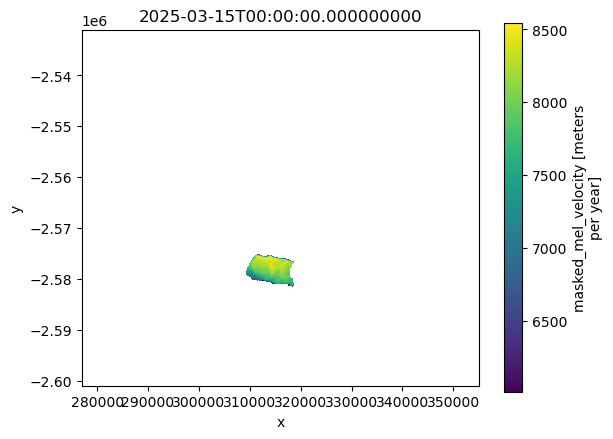

In [144]:
da = ds.masked_mel_velocity.sel(time="2025-03-15", method="nearest")

# or by index
# da = ds.masked_mel_velocity.isel(time=0)

da.plot(x="x", y="y", cmap="viridis")
plt.gca().set_aspect("equal")
plt.title(str(da.time.values))
plt.show()

In [6]:
ds_2025

<xarray.DataArray 'masked_mel_velocity' (time: 25, y: 1400, x: 1560)> Size: 218MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(25, 1400, 1560), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 200B 2025-01-12 2025-01-24 ... 2025-12-20
  * y        (y) float64 11kB -2.531e+06 -2.531e+06 ... -2.601e+06 -2.601e+06
  * x        (x) float64 12kB 2.77e+05 2.771e+05 ... 3.549e+05 3.55e+05
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [84]:
duration_days

<xarray.DataArray 'duration' (time: 464)> Size: 4kB
array([ 0.,  0.,  0., 12., 12., 10., 14., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 10., 14., 12., 12.,
       24., 12., 12., 12., 12.,  6.,  6.,  6.,  2., 10.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  2., 10.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  0.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  2., 10.,  2.,
       10.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  2., 10.,  2., 10.,  6.,  6.,  6.,  2., 10.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  2., 10.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  2., 10.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  2., 10.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  2., 10.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12.,  2., 22., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,
       12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.,  6.,
        6.,  6.,  6.,  6.,  6., 10.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.])
Coordinates:
  * time     (time) datetime64[ns] 4kB 2015-01-19 2015-01-31 ... 2025-12-20
Attributes:
    description:  duration of temporal baseline, i.e., the time separation of...

In [264]:
ds.velocity_over_melange

<xarray.DataArray 'velocity_over_melange' (time: 354, y: 560, x: 580)> Size: 460MB
[114979200 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 2015-01-27 2015-02-08 ... 2025-01-22
  * y        (y) float64 4kB -1.629e+06 -1.629e+06 ... -1.657e+06 -1.657e+06
  * x        (x) float64 5kB -3.44e+05 -3.439e+05 ... -3.151e+05 -3.15e+05
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over melanged region, excluding...

In [34]:
xs = merged_flow.geoms[0].coords.xy[0]
ys = merged_flow.geoms[0].coords.xy[1]

NameError: name 'merged_flow' is not defined

In [36]:
polygons_gdf["Area"] = polygons_gdf.geometry.area #pd.to_datetime(termini0_taryn["Date"],format='%Y-%m-%d')
polygons_gdf["Date"] = lines_gdf["Date"]
polygons_gdf.iloc[0]

geometry    POLYGON ((310818.0074105491 -2572676.848670863...
Area                                         198430360.654895
Date                                      2015-01-17 00:00:00
Name: 0, dtype: object

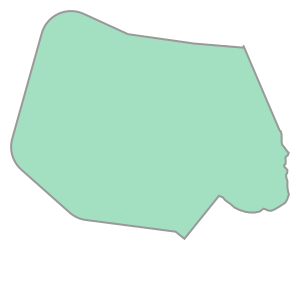

In [26]:
#polygons_gdf.iloc[0].geometry

In [39]:
polygons_gdf.loc[polygons_gdf["Area"] == np.min(polygons_gdf["Area"])]

,geometry,Area,Date,Area_km,Area_change_km
364,"POLYGON ((491849.384 -1085979.867, 492985.052 ...",285684.942407,2022-04-21 00:00:00,0.285685,-1198.559042
365,"POLYGON ((491849.384 -1085979.867, 492985.052 ...",285684.942407,2022-04-21 00:00:00,0.285685,-1198.559042
366,"POLYGON ((491849.384 -1085979.867, 492985.052 ...",285684.942407,2022-04-21 00:00:00,0.285685,-1198.559042


In [31]:
differences0 = polygons_gdf.geometry.area.diff()
differences0[45]

np.float64(0.0)

In [37]:
#use this block to get terminus area change instead of along flowline
polygons_gdf["Area_km"] = polygons_gdf["Area"]*0.000001
polygons_gdf["Area_change_km"] = (-1)*(polygons_gdf["Area_km"] - polygons_gdf["Area_km"].iloc[0])
polygons_gdf.plot(kind="line", x="Date", y="Area_change_km",title="Alison")
#plt.show()

<Axes: title={'center': 'Alison'}, xlabel='Date'>

In [38]:
#get melange area after reading in ds
x_res, y_res = ds.rio.resolution()
pixel_area = abs(x_res * y_res)
sum_pixels = mask.sum(dim=["x", "y"])
melange_area_km = sum_pixels * pixel_area * 0.000001

In [136]:
polygons_gdf["Melange_Area"] = melange_area_km
polygons_gdf.to_csv(f'melange_{name}_geodata.csv', index=False)

In [192]:
polygons_gdf

,geometry,Area,Date,Area_km,Area_change_km
0,"POLYGON ((-324606.48 -1639263.139, -322214.045...",1.272955e+08,2021-12-21 00:00:00,127.29549,-0.0


In [39]:
plt.close('all')

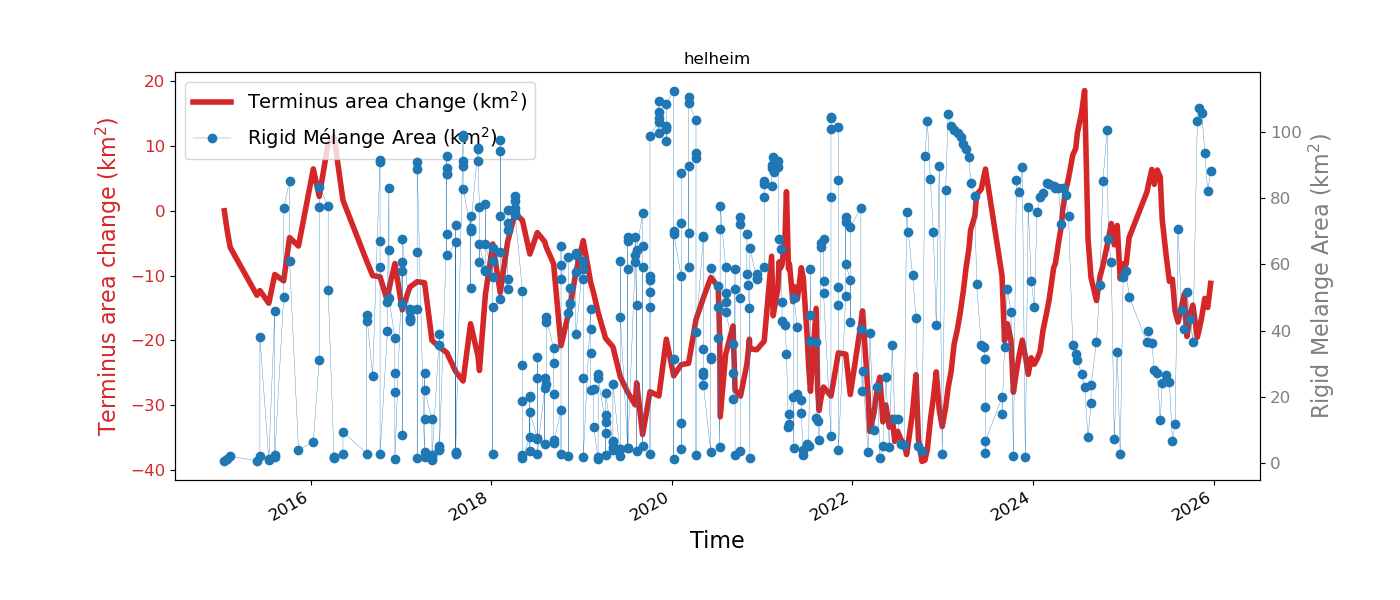

In [40]:
melange_area_km = xr.where(melange_area_km < 0, np.nan, melange_area_km)
#plt.close('all')
#%matplotlib widget

fig, ax1 = plt.subplots(figsize=(14, 6)) # Adjust figure size as needed

# --- 3. Plot the first dataset on ax1 ---
color1 = 'tab:red'
#lab = f'{name}_flow/S1mosaic_nw4B_2021-10-10.tif'
polygons_gdf.plot(kind="line", x="Date", y="Area_change_km",ax=ax1,color=color1, linewidth=4,
                  title=f'{name}', label='Terminus area change (km$^2$)')

ax1.set_xlabel('Time',fontsize=16)
#ax1.set_ylim(-15, 5) 
ax1.set_ylabel('Terminus area change (km$^2$)', color=color1,fontsize=16)
ax1.tick_params(labelsize=12)

# --- 4. Create the secondary axes (ax2) sharing the x-axis ---
ax2 = ax1.twinx()
#ax2.plot(x, data1, color=color1, label='exp(x)')
ax1.tick_params(axis='y', labelcolor=color1,labelsize=12) # Color the ticks to match the line

# --- 5. Plot the second dataset on ax2 ---
color2 = 'tab:gray'
#melange_area_km0 = melange_area_km.rolling(window=7).mean()
ax2.plot(polygons_gdf["Date"],melange_area_km,'o-',linewidth=0.25,label='Rigid Mélange Area (km$^2$)')
ax2.set_ylabel('Rigid Melange Area (km$^2$)', color=color2, fontsize=16) # Label the secondary y-axis
#ax2.plot(polygons_gdf["Date"],melange_area_km)
#plt.plot(, data2, color=color2, label='sin(2*pi*x)')
ax2.tick_params(axis='y', labelcolor=color2,labelsize=12) # Color the ticks to match the line
#ax2.set_ylim(0, 70) 

# --- 6. Add a title and ensure a tight layout ---
#plt.title('Line Plot with Two Y-Axes and Shared X-Axis')
#fig.tight_layout() # Ensures labels and titles don't get clipped

# Combine legends if desired
lines = [ax1.get_lines()[0], ax2.get_lines()[0]]
ax1.legend(lines, [line.get_label() for line in lines], loc='upper left',fontsize=14)
#fig.tight_layout()
plt.show()
#plt.savefig("alison_melange_plot1.png")

In [43]:
clipped_lines = gpd.clip(melmel, polygons_gdf)
clipped_lines
longest = clipped_lines.loc[clipped_lines.length == np.max(clipped_lines.length)]
distances0 = np.arange(250, longest.length.item(), 250)
distances0

array([  250.,   500.,   750.,  1000.,  1250.,  1500.,  1750.,  2000.,
        2250.,  2500.,  2750.,  3000.,  3250.,  3500.,  3750.,  4000.,
        4250.,  4500.,  4750.,  5000.,  5250.,  5500.,  5750.,  6000.,
        6250.,  6500.,  6750.,  7000.,  7250.,  7500.,  7750.,  8000.,
        8250.,  8500.,  8750.,  9000.,  9250.,  9500.,  9750., 10000.,
       10250., 10500., 10750., 11000., 11250., 11500., 11750., 12000.,
       12250., 12500., 12750., 13000., 13250., 13500., 13750., 14000.,
       14250., 14500., 14750., 15000., 15250., 15500., 15750., 16000.,
       16250., 16500., 16750., 17000., 17250., 17500., 17750., 18000.,
       18250., 18500., 18750., 19000., 19250., 19500., 19750., 20000.,
       20250.])

In [175]:
#points = MultiPoint([trim_gate.interpolate(distance) for distance in distances]) 
distances = np.float32([shapely.line_locate_point(output_flow_parts[0].iloc[2].geometry,Point(pts),normalized=False) for pts in output_flow_parts[0].explode().iloc[2].geometry.coords])
distances

array([    0.     ,   622.16345,  1463.6335 ,  2292.6235 ,  3111.342  ,
        3921.5422 ,  4721.0117 ,  5511.147  ,  6292.096  ,  7065.3267 ,
        7831.919  ,  8590.975  ,  9345.671  , 10098.494  , 10845.866  ],
      dtype=float32)

In [ ]:
fig, ax = plt.subplots()


len1 = output_flow_parts[0].iloc[2].geometry.length
bb = np.float32(len1 - 250)
distances = np.arange(250, bb, 250) 
points = [output_flow_parts[0].iloc[2].geometry.interpolate(distance) for distance in distances]
xyarray = shapely.get_coordinates(points)
xyarray.__dir__()
x1 = [x[0] for x in xyarray]
y1 = [x[1] for x in xyarray]
xs = xr.DataArray(x1, dims='distance') 
ys = xr.DataArray(y1, dims='distance') 
vv2 = ds.masked_mel_velocity.interp(x=xs, y=ys, method='linear')

In [287]:
s = (len(output_flow_parts[0].geometry),len(distances0))
vv2 = np.ones(s) * np.nan
vv2.shape

(7, 47)

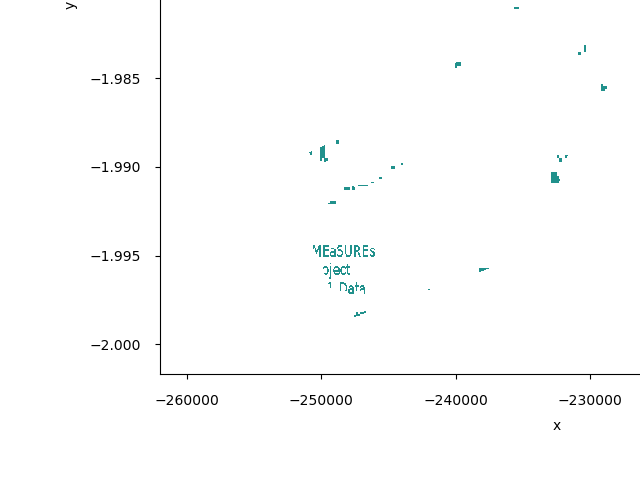

In [305]:
#fig, ax = plt.subplots()
#masked_duration.isel(time=90).plot(cmap='viridis')
#plt.show()

In [7]:

yearly_mean = da.groupby("time.year").mean(dim="time")
yearly_mean = yearly_mean.rename({"year": "time"}) 
yearly_sum = masked_duration.groupby("time.year").sum(dim="time")
yearly_sum = yearly_sum.rename({"year": "time"}) 
masked = xr.where(yearly_sum == 0, np.nan, yearly_sum)

In [52]:
yearly_mean 

<xarray.DataArray 'masked_mel_velocity' (time: 10, y: 560, x: 580)> Size: 13MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(10, 560, 580), dtype=float32)
Coordinates:
  * time     (time) int64 80B 2015 2016 2017 2018 2019 2020 2021 2023 2024 2025
  * y        (y) float64 4kB -1.629e+06 -1.629e+06 ... -1.657e+06 -1.657e+06
  * x        (x) float64 5kB -3.44e+05 -3.439e+05 ... -3.151e+05 -3.15e+05
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [248]:
cogsIM[10]

np.str_('/home/michalea/Documents/S1_rename/alison/mosaics/S1mosaic_alison_2015-12-17.tif')

In [45]:
plt.close('all') 

In [69]:
np.max(alpha)

<xarray.DataArray ()> Size: 8B
array(1.)
Coordinates:
    time     int64 8B 2024
Attributes:
    description:  duration of temporal baseline, i.e., the time separation of...

In [254]:
base.__dir__()

['AREA_OR_POINT',
 'T',
 '_FillValue',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__dask_graph__',
 '__dask_keys__',
 '__dask_layers__',
 '__dask_optimize__',
 '__dask_postcompute__',
 '__dask_postpersist__',
 '__dask_scheduler__',
 '__dask_tokenize__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__mat

In [44]:
base = rio.open_rasterio(cogsIM[10]).squeeze()
fig, ax = plt.subplots()
base.plot(ax=ax, cmap='gray')

In [265]:
data.y.values.max()

np.float64(-1629025.0)

In [80]:
data = yearly_sum.isel(time=-1)
np.max(data)

<xarray.DataArray ()> Size: 8B
array(160.)
Coordinates:
    time     int64 8B 2025
Attributes:
    description:  duration of temporal baseline, i.e., the time separation of...

In [ ]:
yearly_mean = da.groupby("time.year").mean(dim="time")
yearly_mean = yearly_mean.rename({"year": "time"}) 
yearly_sum = masked_duration.groupby("time.year").sum(dim="time")
yearly_sum = yearly_sum.rename({"year": "time"}) 
masked = xr.where(yearly_sum == 0, np.nan, yearly_sum)


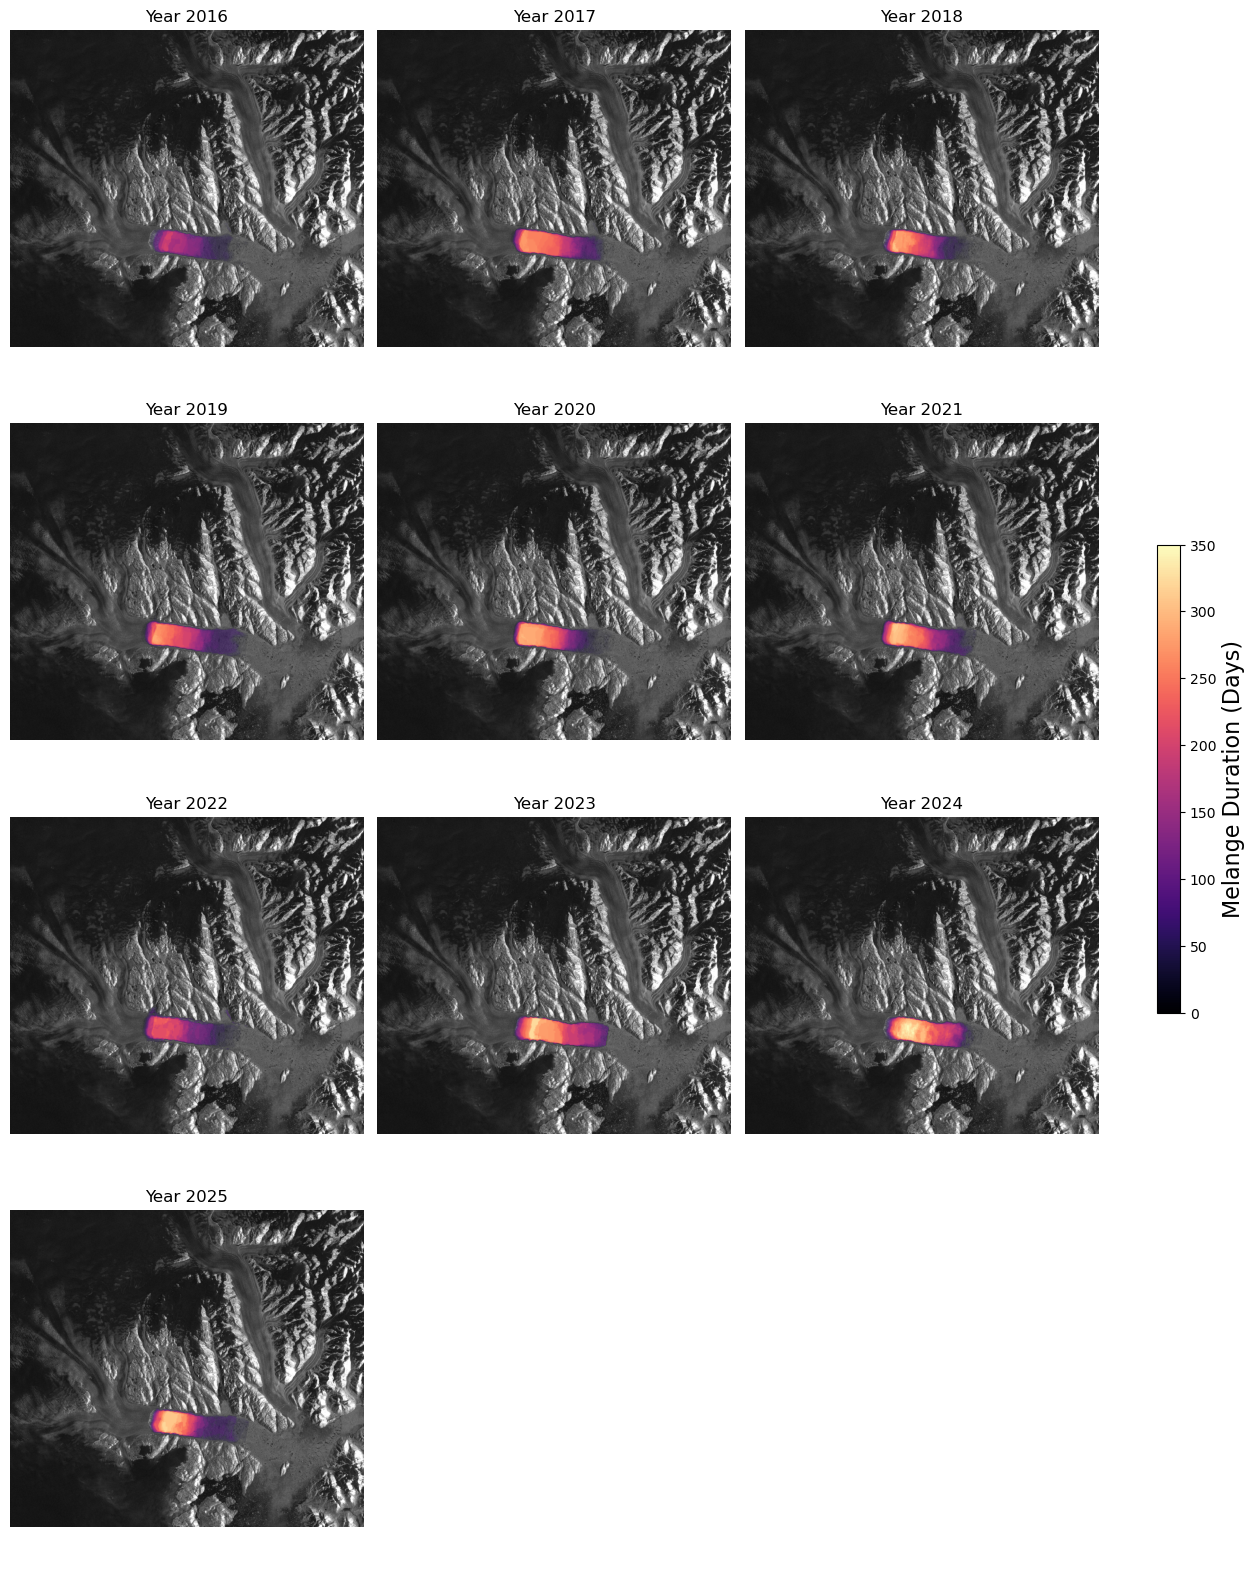

In [11]:
#alp = masked / 350
#alp[np.isnan(alp)] = 0
#alp[alp > 1] = 1
%matplotlib inline
#rio.open_rasterio

yearly_mean = da.groupby("time.year").mean(dim="time")
yearly_mean = yearly_mean.rename({"year": "time"}) 
yearly_sum = masked_duration.groupby("time.year").sum(dim="time")
yearly_sum = yearly_sum.rename({"year": "time"}) 
masked = xr.where(yearly_sum == 0, np.nan, yearly_sum)


#base = rio.open_rasterio(f'{name}_flow/S1mosaic_nw4B_2021-10-10.tif').squeeze()
base = rio.open_rasterio(cogsIM[10]).squeeze()
extent_IM = [np.min(base.x), np.max(base.x), np.min(base.y), np.max(base.y)]
#extent_IM = [np.min(masked.x), np.max(masked.x), np.min(masked.y), np.max(masked.y)]
vmin = float(yearly_sum.min())
vmax = float(yearly_sum.max())

import math

#to exclude 2015 and 2025
yearly_sum = yearly_sum[1:,:,:]
yearly_sum[-1,:,:] = yearly_sum[-1,:,:]*2
masked = xr.where(yearly_sum == 0, np.nan, yearly_sum)
# Select years to plot
n_years = len(yearly_sum.time)
ncols = 3
nrows = math.ceil(n_years / ncols)

extent = [
    yearly_sum.x.values.min(), yearly_sum.x.values.max(),
    yearly_sum.y.values.min(), yearly_sum.y.values.max()
]

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten() 


# Loop through each year
for i in range(n_years):
    ax = axes[i]
    data = yearly_sum.isel(time=i) #yearly_mean.isel(time=i) #
    data = data.where(data < 350,0)
    year_label = int(data['time'].values)
    vmin = float(data.min())
    vmax = float(data.max())

    #year_label = str(data['time'].dt.year.values)
    #year_label = str(int(data['time'].values))

     # Normalize and create alpha (set 0 or NaN to transparent)
    norm = (data - data.min()) / 150 #(data.max() - data.min())
    alpha = norm.where(data > 0, 0)  # More opaque for higher values
    alpha = alpha.where(alpha < 1, 1)
    
    #alpha = alpha.where(alpha > 0, 0)

    extent = [
        data.x.values.min(), data.x.values.max(),
        data.y.values.min(), data.y.values.max()
    ]
    #base.plot(ax=ax, cmap='gray')
    #alp = masked.isel(time=i) / 350
    #data_2d = masked.isel(time=i)
    ax.imshow(
        base.values,
        cmap="gray",            # or 'Greys_r' if single-band
        extent=extent_IM,
        origin="upper"
    )

    # Overlay heatmap with alpha
    im = ax.imshow(
        data.values,
        cmap='magma',
        alpha=alpha.values,
        extent=extent,
        origin='upper',    
        vmin=0,#vmin,
        vmax=350 #vmax
    )

    ax.set_title(f"Year {year_label}")
   # ax.set_xlim(extent[0] + 10000, extent[1] - 18000) #(v1[0] + x_zoom - 5000,v1[2] - x_zoom)
    
    #ax.set_ylim(extent[2] + 10000, extent[3] - 10000)
    ax.set_axis_off()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
    
plt.tight_layout()
cbar = fig.colorbar(im, ax=axes, orientation='vertical',fraction = 0.02,shrink=0.75)#,fraction=0.02) #, shrink=0.75, pad=0.01)
#plt.colorbar(hi,label='m',extend='max',orientation='horizontal',shrink=0.6)
cbar.set_label("Melange Duration (Days)", fontsize=16) 

In [149]:
mn = np.nanmean(yearly_sum,0).squeeze()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

In [146]:
yearly_sum

<xarray.DataArray (time: 9, y: 1400, x: 1560)> Size: 157MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(9, 1400, 1560))
Coordinates:
  * time     (time) int64 72B 2016 2017 2018 2019 2020 2021 2022 2023 2024
  * y        (y) float64 11kB -2.531e+06 -2.531e+06 ... -2.601e+06 -2.601e+06
  * x        (x) float64 12kB 2.77e+05 2.771e+05 ... 3.549e+05 3.55e+05
Attributes:
    description:  duration of temporal baseline, i.e., the time separation of...

In [ ]:
#alp = masked / 350
#alp[np.isnan(alp)] = 0
#alp[alp > 1] = 1
%matplotlib inline
#rio.open_rasterio

yearly_mean = da.groupby("time.year").mean(dim="time")
yearly_mean = yearly_mean.rename({"year": "time"}) 
yearly_sum = masked_duration.groupby("time.year").sum(dim="time")
yearly_sum = yearly_sum.rename({"year": "time"}) 
masked = xr.where(yearly_sum == 0, np.nan, yearly_sum)


mn = np.nanmean(yearly_sum,0).squeeze()

#base = rio.open_rasterio(f'{name}_flow/S1mosaic_nw4B_2021-10-10.tif').squeeze()
base = rio.open_rasterio(cogsIM[10]).squeeze()
extent_IM = [np.min(base.x), np.max(base.x), np.min(base.y), np.max(base.y)]
#extent_IM = [np.min(masked.x), np.max(masked.x), np.min(masked.y), np.max(masked.y)]
vmin = float(yearly_sum.min())
vmax = float(yearly_sum.max())

import math

#to exclude 2015 and 2025
yearly_sum = yearly_sum[1:,:,:]
masked = xr.where(yearly_sum == 0, np.nan, yearly_sum)
# Select years to plot
n_years = len(yearly_sum.time)
ncols = 3
nrows = math.ceil(n_years / ncols)

extent = [
    yearly_sum.x.values.min(), yearly_sum.x.values.max(),
    yearly_sum.y.values.min(), yearly_sum.y.values.max()
]

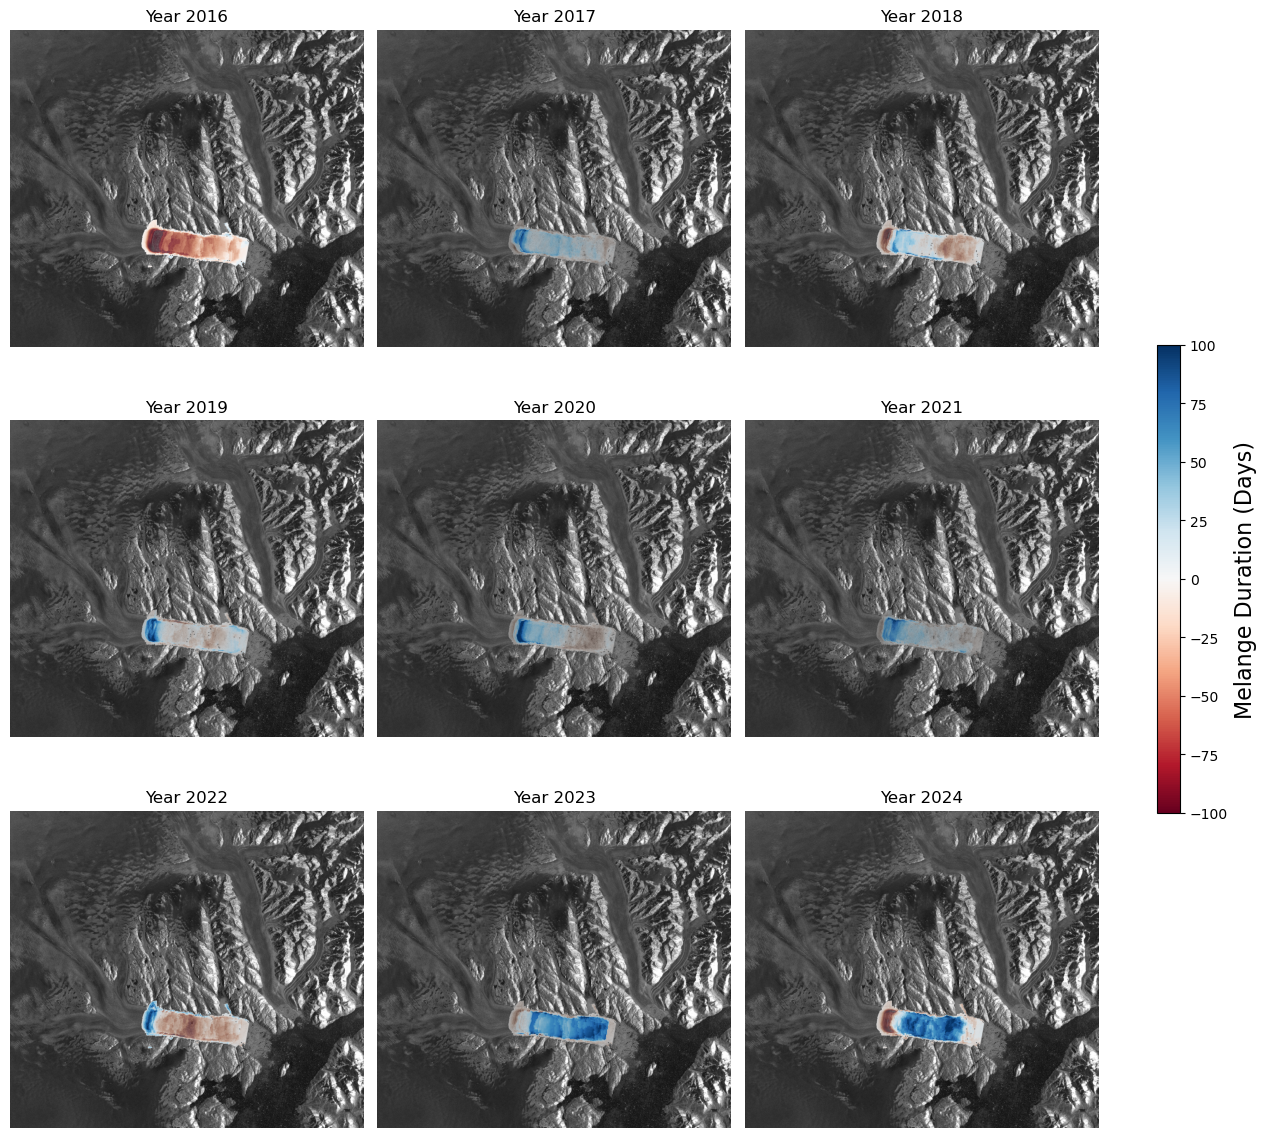

In [155]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten() 


# Loop through each year
for i in range(n_years):
    ax = axes[i]
    data = yearly_sum.isel(time=i)  - mn#yearly_mean.isel(time=i) #
    #data = data.where(data < 350,0)
    year_label = int(data['time'].values)
    vmin = float(data.min())
    vmax = float(data.max())

    #year_label = str(data['time'].dt.year.values)
    #year_label = str(int(data['time'].values))

     # Normalize and create alpha (set 0 or NaN to transparent)
    norm = (data - data.min()) / 150 #(data.max() - data.min())
    alpha = norm.where(data != 0, 0)  # More opaque for higher values
    alpha = alpha.where(alpha < 1, 1)
    
    #alpha = alpha.where(alpha > 0, 0)

    extent = [
        data.x.values.min(), data.x.values.max(),
        data.y.values.min(), data.y.values.max()
    ]
    #base.plot(ax=ax, cmap='gray')
    #alp = masked.isel(time=i) / 350
    #data_2d = masked.isel(time=i)
    ax.imshow(
        base.values,
        cmap="gray",            # or 'Greys_r' if single-band
        extent=extent_IM,
        origin="upper"
    )

    # Overlay heatmap with alpha
    im = ax.imshow(
        data.values,
        cmap='RdBu',
        alpha=alpha.values,
        extent=extent,
        origin='upper',    
        vmin=-100,#vmin,
        vmax=100 #vmax
    )

    ax.set_title(f"Year {year_label}")
   # ax.set_xlim(extent[0] + 10000, extent[1] - 18000) #(v1[0] + x_zoom - 5000,v1[2] - x_zoom)
    
    #ax.set_ylim(extent[2] + 10000, extent[3] - 10000)
    ax.set_axis_off()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
    
plt.tight_layout()
cbar = fig.colorbar(im, ax=axes, orientation='vertical',fraction = 0.02,shrink=0.75)#,fraction=0.02) #, shrink=0.75, pad=0.01)
#plt.colorbar(hi,label='m',extend='max',orientation='horizontal',shrink=0.6)
cbar.set_label("Melange Duration (Days)", fontsize=16) 

In [46]:
ss = (len(ds.time),len(distances0))
mean_vv2 = np.ones(ss) * np.nan
m = np.ones((len(ds.time),1)) * np.nan
m1km = np.ones((len(ds.time),1)) * np.nan
m3km = np.ones((len(ds.time),1)) * np.nan
m5km = np.ones((len(ds.time),1)) * np.nan
m10km = np.ones((len(ds.time),1)) * np.nan
s = (len(output_flow_parts[0].geometry),len(distances0))
vv2 = np.ones(s) * np.nan



for ii in range(len(ds.time)):
    vv2 = np.ones(s) * np.nan
    for i in range(len(output_flow_parts[0].geometry)):
        #print('hi')
        points = [output_flow_parts[ii].iloc[i].geometry.interpolate(distance) for distance in distances0]
        ptss = shapely.get_coordinates(points)
        #ptss = shapely.line_interpolate_point(clipped_lines[i], distances0)
        #x1 = [item.x  for item in ptss]
        #y1 = [item.y  for item in ptss]
        #xs = xr.DataArray(x1, dims='distance')
        #ys = xr.DataArray(y1, dims='distance')
        x1 = [x[0] for x in ptss]
        y1 = [x[1] for x in ptss]
        xs = xr.DataArray(x1, dims='distance') 
        ys = xr.DataArray(y1, dims='distance')
        vv2[i,:] = ds.masked_mel_velocity.isel(time=ii).interp(x=xs, y=ys, method='linear')
        #distances0 = np.float32([shapely.line_locate_point(longest,Point(pts),normalized=False) for pts in longest.coords])
        
    mean_vv2[ii,:] = np.nanmean(vv2,axis=0) 
    a = 0.001*np.float32(distances0)
    bb = mean_vv2[ii,:]
    m1km[ii], b = np.polyfit(a[:3],bb[:3], 1)
    m3km[ii], b = np.polyfit(a[:11],bb[:11], 1)
    m5km[ii], b = np.polyfit(a[:19],bb[:19], 1)
    m10km[ii], b = np.polyfit(a[:39],bb[:39], 1)
    #m[ii], b = np.polyfit(a[:30],bb[:30], 1)

    

In [100]:
a[39]

np.float32(10.0)

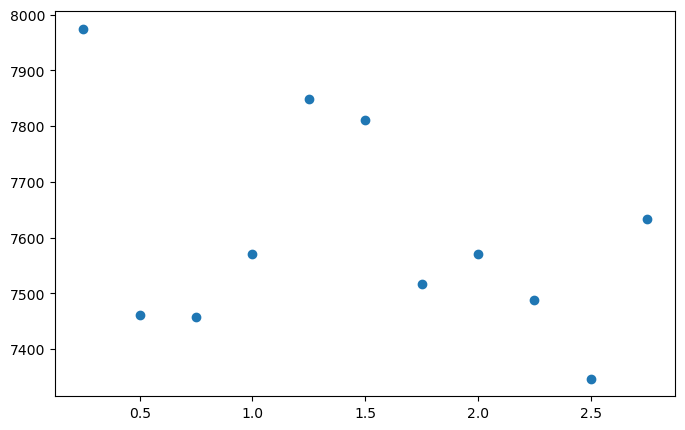

In [47]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(a[:11],bb[:11])

In [84]:
differences0[2,:]


array([4527.89935507, 4127.89935507, 3727.89935507, 3327.89935507,
       2927.89935507, 2527.89935507, 2127.89935507, 1727.89935507,
       1327.89935507,  927.89935507,  527.89935507,  127.89935507,
        272.10064493,  672.10064493, 1072.10064493, 1472.10064493,
       1872.10064493, 2272.10064493, 2672.10064493, 3072.10064493])

In [57]:
from matplotlib.pyplot import cm
trends0 = m5km#elements["melting point"]
trends_inds = np.arange(-500, 500, 50, dtype=np.int_)
colorm = cm.twilight_shifted(np.linspace(0, 1, len(trends_inds)))
differences0 = np.abs(m10km[:, np.newaxis] - trends_inds).squeeze()
closest_indices = np.argmin(differences0, axis=1)

In [79]:
closest_indices

array([ 0,  9,  0,  0,  0,  0,  0,  9,  0,  9, 11,  0, 10, 10,  0,  0, 10,
        0, 10, 10, 11,  0,  0,  0,  0,  0,  0,  0,  0,  9, 10,  0,  8,  0,
       10, 10, 10, 10, 10,  0, 10,  0, 10,  0, 10, 10, 10, 10,  0,  9, 10,
       10, 10, 10, 10, 10, 11, 10, 10, 10,  0,  9, 10, 10, 10, 10, 11, 10,
       11, 11, 10, 11, 11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, 10, 13,  0, 11, 19, 14,  0, 13,  9, 19, 10, 19, 16,  9,  0,
       14,  0, 12,  0, 10, 11, 10,  0, 10, 10, 11, 10, 11, 19, 10,  0,  9,
        9,  9, 11,  9, 12, 10, 10, 14,  7,  9,  0,  0,  0,  0,  0,  0,  0,
       16,  0,  0,  0, 19, 11,  0, 10,  0,  9,  9, 10, 10, 16,  0, 10,  0,
       12,  0, 10,  0, 10, 10, 16,  9, 10,  0, 10, 10, 11,  9, 10, 10, 11,
       10, 10,  0, 10, 12, 10, 13,  9,  0,  9, 10, 10,  0,  0, 10,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  7,  0,  8,  9,
        9, 10,  9, 10, 10

In [53]:
#colorm = cm.twilight_shifted(np.linspace(0, 1, len(trends_inds)))
colorm2 = colorm[closest_indices]
colorm2

array([[0.18739228, 0.0771021 , 0.21618875, 1.        ],
       [0.18739228, 0.0771021 , 0.21618875, 1.        ],
       [0.18739228, 0.0771021 , 0.21618875, 1.        ],
       ...,
       [0.87571459, 0.83553023, 0.84575538, 1.        ],
       [0.37264167, 0.37225835, 0.70242873, 1.        ],
       [0.71500403, 0.78426487, 0.81311117, 1.        ]], shape=(464, 4))

In [58]:
colorm = cm.RdBu(np.linspace(0, 1, len(trends_inds)))
colorm2 = colorm[closest_indices]
arr = np.isnan(trends0).squeeze()
mask0 = arr == True

In [59]:
#mask0.dtype
colorm2[mask0,3] = 0
colorm2
alpha02 = np.ones(len(colorm2))
alpha02[mask0] = 0
markerfacealpha0 = colorm2[:,3]
markerfacealpha0

array([0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0.,
       0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1.,
       0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0.,
       0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1.,
       1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [100]:
valid_mask.squeeze().shape

(434,)

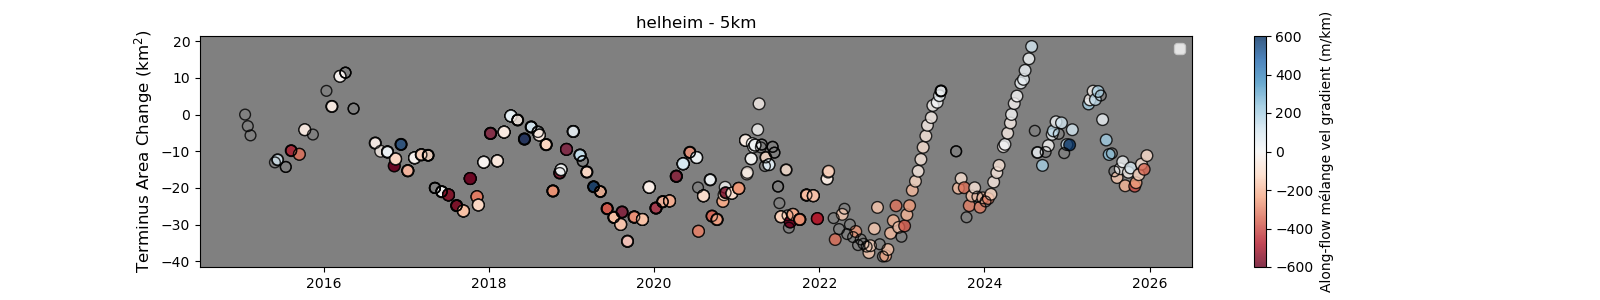

In [61]:
# Define colormap and normalization
%matplotlib widget
import matplotlib.colors as mcolors
cmap = plt.get_cmap('RdBu')
norm = mcolors.Normalize(vmin=-600, vmax=600)

# Separate valid and NaN indices
valid_mask = ~np.isnan(trends0) #polygons_gdf["Area_change_km"])
nan_mask = ~valid_mask

fig, ax = plt.subplots(figsize=(16,3))
ax.set_facecolor('gray')

# Plot valid (filled) markers using `c=` so colorbar links correctly
sc = ax.scatter(
    polygons_gdf["Date"][valid_mask.squeeze()],
    polygons_gdf["Area_change_km"][valid_mask.squeeze()],
    c=trends0[valid_mask.squeeze()], #polygons_gdf["Area_change_km"][valid_mask],  # <-- use `c=`, not `color=`
    cmap=cmap,
    norm=norm,
    s=70,
    edgecolors="black",
    alpha=0.8,
    #label='Terminus area change (km²)'
)

# Plot NaN markers as hollow (facecolors='none')
ax.scatter(
    polygons_gdf["Date"][nan_mask.squeeze()],
    polygons_gdf["Area_change_km"][nan_mask.squeeze()],  # or a proxy y-value if all NaN
    facecolors='none',
    edgecolors='black',
    s=60,
    alpha=0.8,#0.3,
    #label='No data'
)
ax.set_ylabel('Terminus Area Change (km$^2$)',fontsize=12)
# Colorbar now correctly links to `sc` mappable
ax.set_title(f"{name} - 5km")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Along-flow mélange vel gradient (m/km)")

plt.legend()
plt.show()

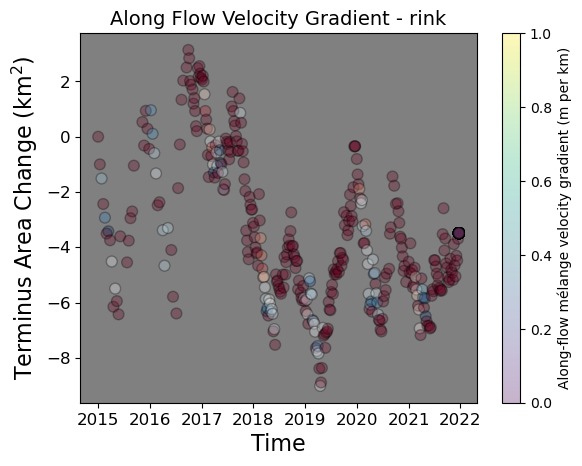

In [92]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots()
# Define colormap and normalization
cmap = plt.get_cmap('RdBu')
norm = mcolors.Normalize(vmin=-2000, vmax=2000)

ax.set_facecolor('gray')
sc = ax.scatter(polygons_gdf["Date"],polygons_gdf["Area_change_km"],c=colorm2,cmap=cmap, norm=norm,s=60,#colorm2[closest_indices],cmap='RdBu',s=60,
                  edgecolors="black",alpha=0.3,label='Terminus area change (km$^2$)')#,title='Along Flow Melange Acceleration - ZI') alpha=alpha02
#cbar = plt.colorbar(sc,cax=ax)
cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label('Area change (km²)')
#plt.colorbar(sc,ax=ax)
#sc2 = ax.scatter(polygons_gdf["Date"],polygons_gdf["Area_change_km"],facecolors='none',s=60,#colorm2[closest_indices],cmap='RdBu',s=60,
#                  edgecolors="black",alpha=0.9,label='Terminus area change (km$^2$)')
ax.set_ylabel('Terminus Area Change (km$^2$)',fontsize=16)
ax.set_xlabel('Time',fontsize=16)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)
plt.title(f'Along Flow Velocity Gradient - {name}',fontsize=14)
#ax.title="Zacharie Isstrom"
#plot.show()
#sc.set_markerfacecolor(markerfacealpha0)

#sc = plt.scatter(x, y, c=colors, cmap='viridis', s=50) # 's' controls marker size

# 3. Add the colorbar, referencing the 'sc' object
#cbar = plt.colorbar(sc)

# 4. Customize the plot and colorbar
#plt.xlabel("X values")
#plt.ylabel("Y values")
#plt.title("Scatter Plot with Colorbar")
cbar.set_label("Along-flow mélange velocity gradient (m per km)") 
plt.show()

In [301]:
mean_vv2

array([[          nan,   27.70165062,           nan, ...,           nan,
                  nan,           nan],
       [ 820.7095638 ,           nan,           nan, ...,  486.8193445 ,
         486.8193445 ,  486.8193445 ],
       [4875.53746904, 4766.93170315, 5299.35132497, ...,           nan,
                  nan,           nan],
       ...,
       [          nan,           nan,           nan, ...,  520.74955185,
         520.74955185,  520.74955185],
       [4418.79833984,           nan,           nan, ...,           nan,
                  nan,           nan],
       [4691.28834299, 4854.03574111, 4906.76352843, ...,           nan,
                  nan,           nan]], shape=(434, 47))

hi
hi
hi
hi


IndexError: index 20 is out of bounds for axis 0 with size 20

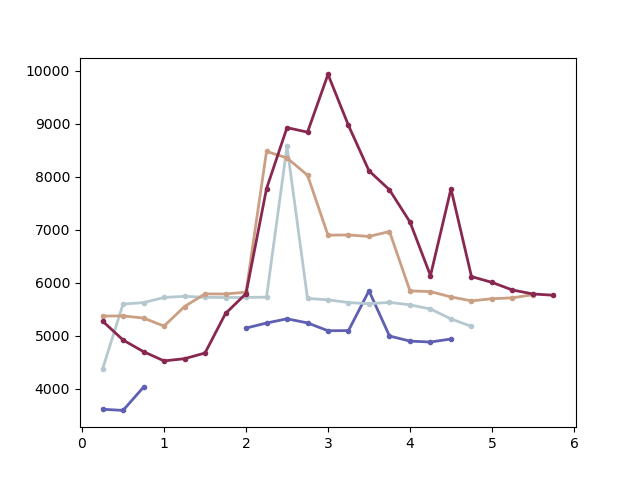

In [299]:
fig, ax = plt.subplots()
date_label0 = ds.time[72].dt.strftime('%Y-%m-%d').item()
#date_label1 = vv2.time[202].dt.strftime('%Y-%m-%d').item()
#date_label2 = vv2.time[203].dt.strftime('%Y-%m-%d').item()
for j in range(len(clipped_lines)):
    ax.plot(0.001*np.float32(distances0),vv2[j,:], '.-',color=colorm[4+4*j],linewidth=2,label=f'flowline {j}')
    print('hi')
    
#ax.plot(np.float32(distances0),vv2, '.-',color=colorm[15],linewidth=1,label=date_label0)
#ax.plot(0.001*np.float32(distances0),np.nanmean(vv2,axis=0), '.-',color=colorm[39],linewidth=4,label=date_label0)
ax.set_xlabel('Distance from terminus(km)', fontsize=16)
ax.set_ylabel('Along-flow velocity (m/yr)', fontsize=16)
#ax.plot(np.float32(distances),vv2[202,:], 'X-',color=colorm[25],label=date_label1)
#ax.plot(np.float32(distances),vv2[203,:], '.-',color=colorm[35],label=date_label2)
plt.legend()

In [297]:
for i in range(len(vv2.time)):
    ax.plot(np.float32(distances),vv2[i,:], '.-',color=colorm[30])
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'time'

In [228]:
vv2[5,:]

<xarray.DataArray 'masked_mel_velocity' (distance: 10)> Size: 80B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])
Coordinates:
    time     datetime64[ns] 8B 2015-03-04
    x        (distance) float64 80B -2.306e+05 -2.314e+05 ... -2.367e+05
    y        (distance) float64 80B -1.982e+06 -1.983e+06 ... -1.989e+06
Dimensions without coordinates: distance
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [223]:
#merged_flow.geoms[0].coords.xy[0]
xr.DataArray(x1, dims='distance') 

<xarray.DataArray (distance: 10)> Size: 80B
array([-230643.98038152, -231441.28028668, -232210.10493821,
       -232952.50407788, -233666.67152464, -234349.02298673,
       -234993.58301487, -235608.26460725, -236191.75922083,
       -236749.22911258])
Dimensions without coordinates: distance

In [ ]:
fig, axes = plt.subplots(np.ceil(len(myFlowlines)/4).astype(int), 4, figsize=(18, 9)) 

da1 = xr.open_dataset(tempFile)
vel = da1.masked_mel_velocity
for ii in range(5)
    for i in range(40):
        xs = [x[0] for x in output_flow_parts[i].explode().iloc[ii].geometry.coords[:]]
        ys = [x[1] for x in output_flow_parts[i].explode().iloc[ii].geometry.coords[:]]
        data_with_crs.masked_mel_velocity.interp(output_flow_parts[i].explode().iloc[ii])

In [ ]:
fig, axes = plt.subplots(np.ceil(len(myFlowlines)/4).astype(int), 4, figsize=(18, 9)) 

#da1 = xr.open_dataset(tempFile)
vel = ds.masked_mel_velocity
for ii in range(5)
    for i in range(40):
        #xs = [x[0] for x in output_flow_parts[i].explode().iloc[ii].geometry.coords[:]]
        #ys = [x[1] for x in output_flow_parts[i].explode().iloc[ii].geometry.coords[:]]
        ds.masked_mel_velocity.interp(output_flow_parts[i].explode().iloc[ii])
        #vv1 = ds.velocity_over_melange.interp({'x':merged_flow.geoms[0].coords.xy[0],'y':merged_flow.geoms[0].coords.xy[1]})
        vv1 = ds.velocity_over_melange.interp({'x':mm.geoms[i].coords.xy[i],'y':mm.geoms[0].coords.xy[1]})

In [212]:
mm.geoms[i].coords.xy[0]

IndexError: index out of range

In [213]:
xs = mm.geoms[0].coords.xy[0]

ys = mm.geoms[0].coords.xy[1]
vv1 = ds.velocity_over_melange.interp({'x':mm.geoms[0].coords.xy[0],'y':mm.geoms[0].coords.xy[1]})

In [215]:
mm.geoms[0].coords.xy[0]

array('d', [-203000.0, -203192.03295852916, -204173.85806331947, -205155.69941713152, -206137.0143618228, -207117.71627990686, -208096.54159507138, -209070.51575581208, -210044.9711159017, -211025.2626525332, -212003.9207955293, -212970.69551076743, -213921.6530647029, -214861.18730076897, -215807.29716392118, -216776.63541006367, -217750.29524838462, -218700.61378198073, -219627.41096127222, -220589.8323502841, -221564.38149029895, -222524.07317281724, -223414.29154719738, -224349.3784684094, -225301.10138468022, -226184.53869364905, -226997.52057264198, -227732.77215930706, -228361.1276294873, -228877.0419754074, -229319.19659084603, -229751.5160293379, -230222.09496944654, -230742.00604562624, -231334.08299959332, -231985.7773775177, -232660.22174592616, -233350.5140205046, -234047.85492143087, -234733.76701421366, -235398.7310403309, -236039.6624219325, -236640.4566581795, -237199.24498492802, -237723.0316997828, -238217.18795246963, -238702.62656929367, -239179.12823693443])

In [ ]:
    d.append(flowline)
    xy = d[i][0]
    ax.plot(flowline[:,0]*1000, flowline[:,1]*1000, '.-',color=colorm[i])
    ax.plot(start_point[0]*1000, start_point[1]*1000, 'o',color='C0')
    ax.plot(xy[0]*1000, xy[1]*1000, 'x',color='r')

In [101]:
len(output_flow_parts)

446

In [ ]:
output_flow_parts[0].iloc[2].geometry.length
bb = np.float32(flux_lines_rink.geometry.length - 500)
distances = np.arange(500, bb, 1000) 
points = [flux_lines_rink.geometry.interpolate(distance) for distance in distances]

In [288]:
merged_flow.geoms[0].coords[2]

(460995.1399084175, -1113001.9171032559)

In [31]:
bb = merged_flow.geoms[0].length
distances = np.arange(500, bb, 1000)
distances

array([ 500., 1500., 2500., 3500., 4500., 5500., 6500., 7500.])

In [97]:
#points = MultiPoint([trim_gate.interpolate(distance) for distance in distances]) 
distances = np.float32([shapely.line_locate_point(merged_flow.geoms[0],Point(pts),normalized=False) for pts in merged_flow.geoms[0].coords])
distances

array([0.0000000e+00, 2.3283064e-10, 4.7282700e-10, 1.1863162e-09,
       5.3773688e-09, 1.4560215e-08, 2.4626987e-08, 1.4087888e-07,
       4.6157419e-07, 6.0806633e-07, 3.5179814e-06, 1.3820728e-05,
       2.3350227e-05, 9.0128153e-05, 4.0040450e-04, 8.7149109e-04,
       2.2129023e-03, 1.1027986e-02, 2.9617971e-02, 5.0503239e-02,
       2.8626561e-01, 9.3842649e-01, 1.2384169e+00, 7.5156159e+00,
       2.7089363e+01, 3.9788773e+01, 7.4050751e+01, 1.5882555e+02,
       2.4349896e+02, 3.1879733e+02, 6.8145325e+02, 9.7053180e+02,
       1.1552185e+03, 1.2586035e+03, 1.3474810e+03, 1.8190253e+03,
       1.9975011e+03, 2.1842126e+03, 2.3710430e+03, 2.6278618e+03,
       3.2310737e+03, 3.5911907e+03, 3.7840269e+03, 3.9161255e+03,
       4.0464312e+03, 4.3010737e+03, 4.7674468e+03, 5.5084121e+03,
       6.2130474e+03, 6.9127300e+03, 7.6043047e+03, 8.3013604e+03],
      dtype=float32)

In [38]:
xs = xr.DataArray(merged_flow.geoms[0].coords.xy[0], dims='distance') #xr.DataArray(xy[:,0], dims='distance')
ys = xr.DataArray(merged_flow.geoms[0].coords.xy[1], dims='distance')
vv2 = ds.velocity_over_melange.interp(x=xs, y=ys, method='linear')
vv2
#ys = xr.DataArray(xy[:,1], dims='distance')

#print(xs.shape)
#print(ys.shape)
#print(vMapY.shape)
#vmap0 = rasterio.open(vel1)
#ctrveli = vel.interp(x=xs, y=ys, method='linear')
#vel1 = vel[:,0,:,:]
#print(type(vel1))
#{'x':merged_flow.geoms[0].coords.xy[0],'y':merged_flow.geoms[0].coords.xy[1]}

<xarray.DataArray 'velocity_over_melange' (time: 434, distance: 52)> Size: 181kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(434, 52))
Coordinates:
  * time     (time) datetime64[ns] 3kB 2015-01-03 2015-01-15 ... 2025-01-22
    x        (distance) float64 416B -2.465e+05 -2.465e+05 ... -2.457e+05
    y        (distance) float64 416B -1.975e+06 -1.975e+06 ... -1.973e+06
Dimensions without coordinates: distance
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over melanged region, excluding...

In [48]:
merged_flow.geom_type

'MultiLineString'

In [58]:
clipped_lines = gpd.clip(melmel, polygons_gdf.geometry[0])
#clipped_lines[0].coords[-1]
distances = np.float32([shapely.line_locate_point(clipped_lines[0],Point(pts),normalized=False) for pts in clipped_lines[0].coords])
#distances
xs = xr.DataArray(clipped_lines[0].coords.xy[0], dims='distance') #xr.DataArray(xy[:,0], dims='distance')
ys = xr.DataArray(clipped_lines[0].coords.xy[1], dims='distance')
vv2 = ds.velocity_over_melange.interp(x=xs, y=ys, method='linear')
vv2

KeyError: 0

In [119]:
distances = np.float32([shapely.line_locate_point(clipped_lines.iloc[0].geoms,Point(pts),normalized=False) for pts in clipped_lines.iloc[0].geoms.coords])
distances

AttributeError: 'LineString' object has no attribute 'geoms'

In [126]:
clipped_lines.iloc[0].coords.xy

(array('d', [-229592.40870988884, -229891.20690459953, -230607.45331499563, -231268.21425194736, -231843.1586876375, -232366.19403082633, -232866.0279888743, -233348.25444032968, -233804.1070060825, -234235.5867254736, -234653.26905146983, -235049.87269581918, -235423.67093194058, -235775.5941224667, -236093.3380190878]),
 array('d', [-1982665.8309334323, -1982895.3233644124, -1983369.944225907, -1983881.065049174, -1984442.6049330863, -1985029.542500644, -1985626.5764686458, -1986230.7536658782, -1986844.9319828558, -1987467.905979343, -1988095.56337915, -1988729.8680981102, -1989371.1271717648, -1990018.414716831, -1990674.348910603]))

In [57]:
clipped_lines.iloc[0].geometry

AttributeError: 'LineString' object has no attribute 'geometry'

In [41]:
#get length

#llp2 = shapely.line_locate_point(merged_flow.geoms[0],Point(merged_flow.geoms[0].coords[-1]),normalized=False)
llp2 = shapely.line_locate_point(clipped_lines[0],Point(clipped_lines[0].coords[-1]),normalized=False)
llp2
# get distance to front intersection to correct for along line distance
intersection_pt = merged_flow.geoms[0].intersection(lines_gdf['geometry'].iloc[0])
llp = shapely.line_locate_point(merged_flow.geoms[0], intersection_pt, normalized=False)


xs = xr.DataArray(merged_flow.geoms[0].coords.xy[0], dims='distance') #xr.DataArray(xy[:,0], dims='distance')
ys = xr.DataArray(merged_flow.geoms[0].coords.xy[1], dims='distance')
vv2 = ds.velocity_over_melange.interp(x=xs, y=ys, method='linear')

KeyError: 0

In [28]:
merged_flow.geoms[0].coords.xy

(array('d', [-246501.5549186634, -246501.5549186634, -246501.55491866334, -246501.5549186632, -246501.55491866317, -246501.55491866454, -246501.55491866934, -246501.55491867336, -246501.55491864253, -246501.55491849783, -246501.55491828336, -246501.55491889073, -246501.55492300197, -246501.5549315995, -246501.55492304298, -246501.55481304045, -246501.55451113282, -246501.554490668, -246501.5572391016, -246501.56696791074, -246501.57510546237, -246501.51234586115, -246501.2152088912, -246500.79776211228, -246502.13989373826, -246508.28186327405, -246515.6719284743, -246523.8718020728, -246515.49675854383, -246440.21982890982, -246339.17663343876, -246368.65457891347, -246437.2635650826, -246523.01310607782, -246592.74502219196, -246842.03643546847, -246885.0483402737, -247034.90671499496, -247149.58267840068, -247182.9181393786, -247124.6507900545, -247030.24613079257, -246939.35598347327, -246841.96725428873, -246712.8644289304, -246601.1566796707, -246320.4194247201, -245904.515274184

In [65]:
from matplotlib.pyplot import cm
colorm = cm.Purples(np.linspace(0, 1, 40)) #len(series.x)))
colorm[0]
frontxy = lines_gdf['geometry'].iloc[0].coords.xy
fullxy = merged_flow.geoms[0].coords.xy
xytest = output_flow_parts[20].iloc[1].geometry.xy #.explode().iloc[1].items()
xytest[1][0]
#output_flow_parts[20].iloc[1].items().__dir__()

fig, ax = plt.subplots()
ax.plot(frontxy[0][:], frontxy[1][:], '.-',color=colorm[30])
ax.plot(xytest[0][:], xytest[1][:], '.-',color=colorm[20])
ax.plot(fullxy[0][:], fullxy[1][:], '.-',color=colorm[15])
ax.plot(xytest[0][0], xytest[1][0], 'x',color='r')
ax.plot(fullxy[0][0], fullxy[1][0], 'x',color='r')
#    xy = d[i][0]
#    ax.plot(flowline[:,0]*1000, flowline[:,1]*1000, '.-',color=colorm[i])
#    ax.plot(start_point[0]*1000, start_point[1]*1000, 'o',color='C0')
#    ax.plot(xy[0]*1000, xy[1]*1000, 'x',color='r')

NameError: name 'output_flow_parts' is not defined

In [79]:
mm = merged_flow.geoms[1:]

In [85]:
mm.geoms[1].coords[0]

(-203000.0, -1976903.345206059)

In [87]:
mm.items()

AttributeError: 'MultiLineString' object has no attribute 'items'

In [125]:
lines_gdf['geometry'].iloc[0].coords.xy

(array('d', [497900.96560001373, 497763.3819999695, 497784.5486998558, 497858.6321001053, 497953.88229990005, 497964.46570014954, 498133.79939985275, 498218.4661998749, 498281.9663000107, 498419.54990005493, 498345.46649980545, 498197.29949998856, 497869.21549987793, 497752.79860019684, 497689.29850006104, 497678.71509981155, 497657.54839992523, 497742.21519994736, 497742.21519994736, 497710.46519994736, 497308.2976999283, 496969.6304001808, 496630.9629998207, 496218.2122001648, 495689.0444998741, 495403.29390001297, 495255.1269001961, 495054.043200016, 494535.458799839, 494450.7919998169, 494313.20839977264, 494080.3745999336, 493868.7074999809, 493678.20709991455, 493466.53999996185, 493392.4565000534, 493350.1230998039, 493254.87290000916, 493011.45580005646, 492662.2051000595, 492376.45450019836, 492111.8706998825, 492006.03709983826, 491847.2867999077, 491752.0366001129, 491688.5364999771, 491445.1192998886, 491222.86889982224, 491021.7850999832, 490915.95160007477, 490693.7010998

In [173]:
endpoint = Point(xytest[0][0], xytest[1][0])
min_distance = endpoint.distance(lines_gdf['geometry'].iloc[0])
min_distance

NameError: name 'xytest' is not defined

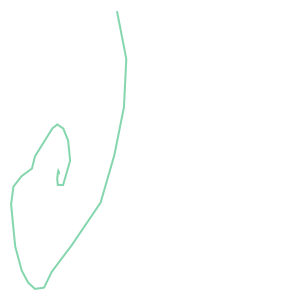

In [172]:
#merged_flow.geoms[0].coords[-1]
endpoint = Point(merged_flow.geoms[0].coords[-1])
merged_flow.geoms[0]

In [171]:
#get length

llp2 = shapely.line_locate_point(merged_flow.geoms[0],Point(merged_flow.geoms[0].coords[-1]),normalized=False)
llp2
# get distance to front intersection to correct for along line distance
intersection_pt = merged_flow.geoms[0].intersection(lines_gdf['geometry'].iloc[0])
llp = shapely.line_locate_point(merged_flow.geoms[0], intersection_pt, normalized=False)
llp2

np.float64(8301.360383095956)

In [245]:
intersection_pt = merged_flow.geoms[0].intersection(lines_gdf['geometry'].iloc[0])
llp = shapely.line_locate_point(merged_flow.geoms[0], intersection_pt, normalized=False)
#llpline_locate_point(line, other
llp

np.float64(37526.499158241924)

In [61]:
for row in output_flow_parts[2].items:
    # 'row' is likely a Series object containing your data for that row
    # You need to access the specific column that holds the LineString geometry
    # Assuming your geometry column is named 'geometry' or similar
    individual_linestring = row['geometry']
    
    # Now you can work with the individual linestring
    print(individual_linestring.length)
    # Example: print its length
    # print(individual_linestring.length) 

TypeError: 'method' object is not iterable

In [68]:
data_with_crs.masked_mel_velocity

NameError: name 'data_with_crs' is not defined

In [127]:
vv1 = data_with_crs.masked_mel_velocity.interp({'x':x1,'y':y1}) #output_flow_parts[0].explode().iloc[3].geometry.xy)
vv1

fig, axes = plt.subplots(np.ceil(len(myFlowlines)/4).astype(int), 4, figsize=(18, 9)) 

da1 = xr.open_dataset(tempFile)
vel = da1.masked_mel_velocity
for ii in range(5)
    for i in range(40):
        xs = [x[0] for x in output_flow_parts[i].explode().iloc[ii].geometry.coords[:]]
        ys = [x[1] for x in output_flow_parts[i].explode().iloc[ii].geometry.coords[:]]
        data_with_crs.masked_mel_velocity.interp(output_flow_parts[i].explode().iloc[ii])
        melvel = vel[i,:,:].interp(x=xs, y=ys, method='linear')

        min_distance = endpoint.distance(line)
        
#vel = da1.velocity
xy = np.array(gdf['geometry'][i].coords)
    maxx= np.max(xy[:,0]) + 5000 
    maxy= np.max(xy[:,1]) + 5000
    minx= np.min(xy[:,0]) - 5000
    miny= np.min(xy[:,1]) - 5000
    bbox = {'minx': minx, 'miny': miny, 'maxx': maxx, 'maxy': maxy} ;
    products.subSetData(bbox) ;
    products.subset;
    tempFile = f'./temp.nc'
    products.subSetToNetCDF(tempFile, numWorkers=10)
    da1 = xr.open_dataset(tempFile)
    vel = da1.velocity
    
    xs = xr.DataArray(xy[:,0], dims='distance')
    ys = xr.DataArray(xy[:,1], dims='distance')
    #FlxVel = vel.interp(x=xs, y=ys, method='linear')
    #vv = FlxVel[:,0,:];
    #ex = FlxVel[:,1,:];
    #ey = FlxVel[:,2,:];
    #ve = np.sqrt(ex**2 + ey**2)
    #dT = FlxVel[:,3,:];
    subsetFile = f'{prefix}/{regionName}_{glacierName}.nc'
    
    FlxVel = vel[:,0,:,:].interp(x=xs, y=ys, method='linear')

line1 = d[0]
lineT = line1.transpose()
#line1[0
#lineT[1]
from shapely.geometry import Point, LineString
from geopandas import GeoSeries
x_data = lineT[0]
y_data = lineT[1]
x1 = [item * 1000 for item in x_data]
y1 = [item * 1000 for item in y_data]
points = GeoSeries(map(Point, zip(x1, y1)))
lineflow0 = LineString(points.tolist())

<xarray.DataArray 'masked_mel_velocity' (time: 446, y: 13, x: 13)> Size: 301kB
dask.array<transpose, shape=(446, 13, 13), dtype=float32, chunksize=(10, 13, 13), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 4kB 2015-01-26 2015-02-14 ... 2024-12-04
    spatial_ref  int64 8B 0
  * x            (x) float64 104B 4.935e+05 4.944e+05 ... 5.063e+05 5.076e+05
  * y            (y) float64 104B -1.1e+06 -1.099e+06 ... -1.095e+06 -1.095e+06
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [ ]:
for ii in range(5)
    for i in range(40):
        data_with_crs.masked_mel_velocity.interp(output_flow_parts[i].explode().iloc[ii])
        output_flow_parts
        output_flow_parts[20].explode().iloc[1] xy(index=flowlineId, units='km'), date=myDate, label=myDate.year, units='km', ax=ax)
        for glacierId, ax in zip(myFlowlines, axes.flatten()):
                for myDate in myVelSeries.time:
        # new plot method
        myVelSeries.plotProfile(*myFlowlines[glacierId].xy(index=flowlineId, units='km'), date=myDate, label=myDate.year, units='km', ax=ax)
        # ax.plot(myFlowlines[glacierId].flowlineDistance(units='km'), speed, label=myDate.year)
    # return interpolated values as vx(time index, distance index)
    # vx, vy, vv = myVelSeries.interp(*myFlowlines[glacierId].xy(units='km'), units='km') 

In [ ]:
flowlineId ='06'  # Flowline id to plot
fig, axes = plt.subplots(np.ceil(len(myFlowlines)/4).astype(int), 4, figsize=(18, 9))  # Setup plot
# Loop over glaciers
for glacierId, ax in zip(myFlowlines, axes.flatten()):
    # return interpolated values as vx(time index, distance index)
    # vx, vy, vv = myVelSeries.interp(*myFlowlines[glacierId].xy(units='km'), units='km') 
    # loop over each profile by time
    for myDate in myVelSeries.time:
        # new plot method
        myVelSeries.plotProfile(*myFlowlines[glacierId].xy(index=flowlineId, units='km'), date=myDate, label=myDate.year, units='km', ax=ax)
        # ax.plot(myFlowlines[glacierId].flowlineDistance(units='km'), speed, label=myDate.year)
    # pretty up plot
    ax.legend(ncol=2, loc='upper right')
    #ax.set_xlabel('Distance (km)', fontsize=13)
    #ax.set_ylabel('Speed (m/yr)', fontsize=13,)
    myVelSeries.labelProfilePlot(ax, title=f'Glacier {glacierId}')
    #ax.set_title(f'Glacier {glacierId}')
for ax in axes.flatten()[len(myFlowlines):]:
    ax.axis('off'); # kill axis with no plot
plt.tight_layout()

## If wishing to animate fields from an existing file, read it in as an xarray. Example provided for Helheim ##

In [ ]:
#ds = xr.open_dataset('/home/michalea/code/melange_helheim_Dec2025.nc')
ds = xr.open_dataset('/home/michalea/code/melange_helheim_Dec2025.nc')
# otherwise, set ds = data_with_crs from concatenated xarray dataset generated above

In [86]:
ds.Time2.values

array(['2015-01-31T00:00:00.000000000', '2015-02-12T00:00:00.000000000',
       '2015-05-31T00:00:00.000000000', '2015-06-12T00:00:00.000000000',
       '2015-06-24T00:00:00.000000000', '2015-07-04T00:00:00.000000000',
       '2015-07-18T00:00:00.000000000', '2015-07-30T00:00:00.000000000',
       '2015-08-11T00:00:00.000000000', '2015-08-23T00:00:00.000000000',
       '2015-09-04T00:00:00.000000000', '2015-09-16T00:00:00.000000000',
       '2015-09-28T00:00:00.000000000', '2015-10-10T00:00:00.000000000',
       '2015-10-22T00:00:00.000000000', '2015-11-27T00:00:00.000000000',
       '2016-01-26T00:00:00.000000000', '2016-02-07T00:00:00.000000000',
       '2016-02-19T00:00:00.000000000', '2016-03-02T00:00:00.000000000',
       '2016-03-14T00:00:00.000000000', '2016-03-26T00:00:00.000000000',
       '2016-04-05T00:00:00.000000000', '2016-04-19T00:00:00.000000000',
       '2016-05-01T00:00:00.000000000', '2016-05-25T00:00:00.000000000',
       '2016-06-30T00:00:00.000000000', '2016-08-05

In [68]:

ds.time.dt.strftime('%Y-%m-%d')


<xarray.DataArray 'strftime' (time: 437)> Size: 3kB
array(['2015-01-19', '2015-01-31', '2015-02-12', '2015-05-31',
       '2015-06-12', '2015-06-24', '2015-07-04', '2015-07-18',
       '2015-07-30', '2015-08-11', '2015-08-23', '2015-09-04',
       '2015-09-16', '2015-09-28', '2015-10-10', '2015-11-15',
       '2016-01-14', '2016-01-26', '2016-02-07', '2016-02-19',
       '2016-03-02', '2016-03-14', '2016-03-26', '2016-04-05',
       '2016-04-19', '2016-05-13', '2016-06-06', '2016-07-24',
       '2016-08-05', '2016-08-17', '2016-08-29', '2016-09-26',
       '2016-10-02', '2016-10-08', '2016-10-14', '2016-10-16',
       '2016-11-01', '2016-11-07', '2016-11-13', '2016-11-19',
       '2016-11-25', '2016-12-01', '2016-12-07', '2016-12-13',
       '2016-12-19', '2016-12-25', '2016-12-31', '2017-01-06',
       '2017-01-12', '2017-01-18', '2017-01-24', '2017-01-30',
       '2017-02-05', '2017-02-11', '2017-02-17', '2017-02-23',
       '2017-03-01', '2017-03-07', '2017-03-13', '2017-03-19',
       '2017-03-25', '2017-03-31', '2017-04-06', '2017-04-12',
       '2017-04-18', '2017-04-24', '2017-04-30', '2017-05-06',
       '2017-05-08', '2017-05-18', '2017-05-24', '2017-05-30',
       '2017-06-05', '2017-06-11', '2017-06-17', '2017-06-23',
       '2017-06-29', '2017-07-05', '2017-07-11', '2017-07-17',
...
       '2022-06-09', '2022-06-21', '2022-07-03', '2022-07-15',
       '2022-07-27', '2022-08-08', '2022-08-20', '2022-09-01',
       '2022-09-13', '2022-09-25', '2022-10-07', '2022-10-19',
       '2022-10-31', '2022-11-12', '2022-11-24', '2022-12-06',
       '2022-12-18', '2022-12-30', '2023-01-11', '2023-01-23',
       '2023-02-04', '2023-02-16', '2023-02-28', '2023-03-12',
       '2023-03-24', '2023-04-05', '2023-04-17', '2023-04-29',
       '2023-05-11', '2023-05-23', '2023-06-04', '2023-06-16',
       '2023-06-28', '2023-07-10', '2023-07-22', '2023-07-24',
       '2023-08-15', '2023-08-27', '2023-09-08', '2023-09-20',
       '2023-10-02', '2023-10-14', '2023-10-26', '2023-11-07',
       '2023-11-19', '2023-12-01', '2023-12-13', '2023-12-25',
       '2024-01-06', '2024-01-18', '2024-01-30', '2024-02-11',
       '2024-02-23', '2024-03-06', '2024-03-18', '2024-03-30',
       '2024-04-11', '2024-04-23', '2024-05-05', '2024-05-17',
       '2024-05-29', '2024-06-10', '2024-06-22', '2024-07-04',
       '2024-07-16', '2024-07-28', '2024-08-09', '2024-08-21',
       '2024-09-02', '2024-09-14', '2024-09-26', '2024-10-08',
       '2024-10-20', '2024-11-01', '2024-11-13', '2024-11-25',
       '2024-12-07'], dtype=object)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2015-01-19 2015-01-31 ... 2024-12-07

In [43]:
ds.time[0]
dates_only_da = ds['time'].dt.date
dates_only_da


<xarray.DataArray 'date' (time: 437)> Size: 3kB
array([datetime.date(2015, 1, 19), datetime.date(2015, 1, 31),
       datetime.date(2015, 2, 12), datetime.date(2015, 5, 31),
       datetime.date(2015, 6, 12), datetime.date(2015, 6, 24),
       datetime.date(2015, 7, 4), datetime.date(2015, 7, 18),
       datetime.date(2015, 7, 30), datetime.date(2015, 8, 11),
       datetime.date(2015, 8, 23), datetime.date(2015, 9, 4),
       datetime.date(2015, 9, 16), datetime.date(2015, 9, 28),
       datetime.date(2015, 10, 10), datetime.date(2015, 11, 15),
       datetime.date(2016, 1, 14), datetime.date(2016, 1, 26),
       datetime.date(2016, 2, 7), datetime.date(2016, 2, 19),
       datetime.date(2016, 3, 2), datetime.date(2016, 3, 14),
       datetime.date(2016, 3, 26), datetime.date(2016, 4, 5),
       datetime.date(2016, 4, 19), datetime.date(2016, 5, 13),
       datetime.date(2016, 6, 6), datetime.date(2016, 7, 24),
       datetime.date(2016, 8, 5), datetime.date(2016, 8, 17),
       datetime.date(2016, 8, 29), datetime.date(2016, 9, 26),
       datetime.date(2016, 10, 2), datetime.date(2016, 10, 8),
       datetime.date(2016, 10, 14), datetime.date(2016, 10, 16),
       datetime.date(2016, 11, 1), datetime.date(2016, 11, 7),
       datetime.date(2016, 11, 13), datetime.date(2016, 11, 19),
...
       datetime.date(2023, 9, 8), datetime.date(2023, 9, 20),
       datetime.date(2023, 10, 2), datetime.date(2023, 10, 14),
       datetime.date(2023, 10, 26), datetime.date(2023, 11, 7),
       datetime.date(2023, 11, 19), datetime.date(2023, 12, 1),
       datetime.date(2023, 12, 13), datetime.date(2023, 12, 25),
       datetime.date(2024, 1, 6), datetime.date(2024, 1, 18),
       datetime.date(2024, 1, 30), datetime.date(2024, 2, 11),
       datetime.date(2024, 2, 23), datetime.date(2024, 3, 6),
       datetime.date(2024, 3, 18), datetime.date(2024, 3, 30),
       datetime.date(2024, 4, 11), datetime.date(2024, 4, 23),
       datetime.date(2024, 5, 5), datetime.date(2024, 5, 17),
       datetime.date(2024, 5, 29), datetime.date(2024, 6, 10),
       datetime.date(2024, 6, 22), datetime.date(2024, 7, 4),
       datetime.date(2024, 7, 16), datetime.date(2024, 7, 28),
       datetime.date(2024, 8, 9), datetime.date(2024, 8, 21),
       datetime.date(2024, 9, 2), datetime.date(2024, 9, 14),
       datetime.date(2024, 9, 26), datetime.date(2024, 10, 8),
       datetime.date(2024, 10, 20), datetime.date(2024, 11, 1),
       datetime.date(2024, 11, 13), datetime.date(2024, 11, 25),
       datetime.date(2024, 12, 7)], dtype=object)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2015-01-19 2015-01-31 ... 2024-12-07

In [40]:
pd.to_datetime(ds.time[0], unit='D')

ValueError: Could not convert object to NumPy datetime

In [24]:
x_res, y_res = ds.rio.resolution()
pixel_area = abs(x_res * y_res)

In [93]:
np.sum(~np.isnan(ds.masked_mel_velocity.loc[ds.time == ds.time[0]])) * pixel_area

<xarray.DataArray 'masked_mel_velocity' ()> Size: 8B
array(1.272725e+08)
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [43]:
# 2. Count the number of non-NaN pixels
# Boolean mask for non-NaN pixels
total_non_nan_area = []
opp = -1
for time in ds.time:
    opp = opp + 1
    #non_nan_mask = ~np.isnan(ds.masked_mel_velocity[j,:,:].values)
    #non_nan_mask = ~np.isnan(ds.masked_mel_velocity.loc[ds.time == time])
    total_non_nan_area[opp] = np.sum(~np.isnan(ds.masked_mel_velocity.loc[ds.time == time])) * pixel_area
    print(total_non_nan_area[opp])
# Count True values in the mask
    #non_nan_pixel_count = np.sum(non_nan_mask)

# 3. Determine the pixel area
# rioxarray.resolution() returns (x_resolution, y_resolution)
    #x_res, y_res = ds.rio.resolution()

# The area of a single pixel is the product of its dimensions.
# Use abs() because resolution can be negative depending on the orientation (e.g., North-up vs South-up).
    #pixel_area = abs(x_res * y_res)

# 4. Calculate the total area of non-NaN pixels
    #total_non_nan_area = non_nan_pixel_count * pixel_area

#total_non_nan_area

IndexError: list assignment index out of range

In [39]:
ds1

<xarray.Dataset> Size: 11GB
Dimensions:                (time: 437, y: 1400, x: 1560)
Coordinates:
  * time                   (time) datetime64[ns] 3kB 2015-01-19 ... 2024-12-07
  * y                      (y) float64 11kB -2.531e+06 -2.531e+06 ... -2.601e+06
  * x                      (x) float64 12kB 2.77e+05 2.771e+05 ... 3.55e+05
Data variables:
    velocity               (time, y, x) float32 4GB ...
    velocity_over_melange  (time, y, x) float32 4GB ...
    masked_mel_velocity    (time, y, x) float32 4GB ...
    Time2                  (time) datetime64[ns] 3kB ...
    duration               (time) timedelta64[ns] 3kB ...
    spatial_ref            int64 8B ...

In [22]:
ds.time[1]

<xarray.DataArray 'time' ()> Size: 8B
array('2015-01-31T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2015-01-31

In [99]:
Vmask2 = V.maskedVel #np.sqrt(Vx.z**2 + Vy.z**2)
Vmask2[Vmask2 < 300] = 0
Vmask2[Vmask2 == 0] = np.NaN
Vmask2[Vmask2 > 0] = 1 #.assign(Vmask=Vmask) V.assign(mask=tottenMask.interp(V.x, V.y, gridded=True))
V.assign(Vmask2=Vmask2)

<xarray.DataArray 'time' ()> Size: 8B
array('2015-01-26T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2015-01-26

In [25]:
total_non_nan_area = []

# Example loop structure
for i in range(len(ds.time)):
    # Simulate some data creation
    time_val = ds.time[i] #pd.to_datetime(f"2023-01-{i+1}")
    data_val = np.sum(~np.isnan(ds.masked_mel_velocity[i,:,:])) * pixel_area #np.random.rand()
    
    # Create a single-point DataArray for the current iteration
    
    # Append to the list
    total_non_nan_area.append(data_val)

new_da = xr.DataArray(
    total_non_nan_area,
    coords={"time": ds.time},
    dims=["time"]
)

KeyboardInterrupt: 

In [85]:
new_da

<xarray.DataArray 'masked_mel_velocity' ()> Size: 8B
array(1.332975e+08)
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [ ]:
y1 = [x[1] for x in output_flow_parts[0].explode().iloc[3].geometry.coords[:]]

In [62]:
#acquire bounds from random read to align set of imagery and velocity overlays in plotting functions below
# --- Load a reference raster for extent ---
mel1 = rasterio.open(cogsM[10])
v1 = mel1.bounds
bb = rio.open_rasterio(cogsIM[10]).squeeze()

extentMel = [mel1.bounds[0],mel1.bounds[2],mel1.bounds[1],mel1.bounds[3]]
extent_IM = [np.min(bb.x), np.max(bb.x), np.min(bb.y), np.max(bb.y)]

x_zoom = (v1[2] - v1[0]) / 4
y_zoom = (v1[3] - v1[1]) / 4

## Declare plotting arguments and precache deogemtries to save time in animation routines ##

In [ ]:
front_data

In [63]:
# One-time preprocessing step to cache geoms as dictionary of coordinates

front_data['xy'] = front_data['geometry'].apply(lambda geom: geom.xy)
front_gdf = gpd.GeoDataFrame(front_data, geometry=front_data.geometry, crs="EPSG:3413")

front_cache = {
    idx: geom.xy
    for idx, geom in front_data['geometry'].items()
}

# --- Load a reference rasters for to predeclare extents and figure zoom arguments---
mel1 = rasterio.open(cogsM[10])
v1 = mel1.bounds
bb = rio.open_rasterio(cogsIM[10]).squeeze()

#velocity map and imagery extents to tie rasterio images to geo in plots 
extentMel = [mel1.bounds[0],mel1.bounds[2],mel1.bounds[1],mel1.bounds[3]]
extent_IM = [np.min(bb.x), np.max(bb.x), np.min(bb.y), np.max(bb.y)]

x_zoom = (v1[2] - v1[0]) / 1
y_zoom = (v1[3] - v1[1]) / 1

## Initialize figure by declaring and rendering artists objects prior to running animation function ##

In [72]:
# --- Load a reference rasters for to predeclare extents and figure zoom arguments---
mel1 = rasterio.open(cogsM[10])
v1 = mel1.bounds
bb = rio.open_rasterio(cogsIM[10]).squeeze()

#velocity map and imagery extents to tie rasterio images to geo in plots 
extentMel = [mel1.bounds[0],mel1.bounds[2],mel1.bounds[1],mel1.bounds[3]]
extent_IM = [np.min(bb.x), np.max(bb.x), np.min(bb.y), np.max(bb.y)]

x_zoom = 1#(v1[2] - v1[0]) / 1
y_zoom = 1#(v1[3] - v1[1]) / 1

In [73]:
overlay_raster1 = ds.velocity[ind,:,:].squeeze()
np.nanmax(overlay_raster1)

np.float32(28478.475)

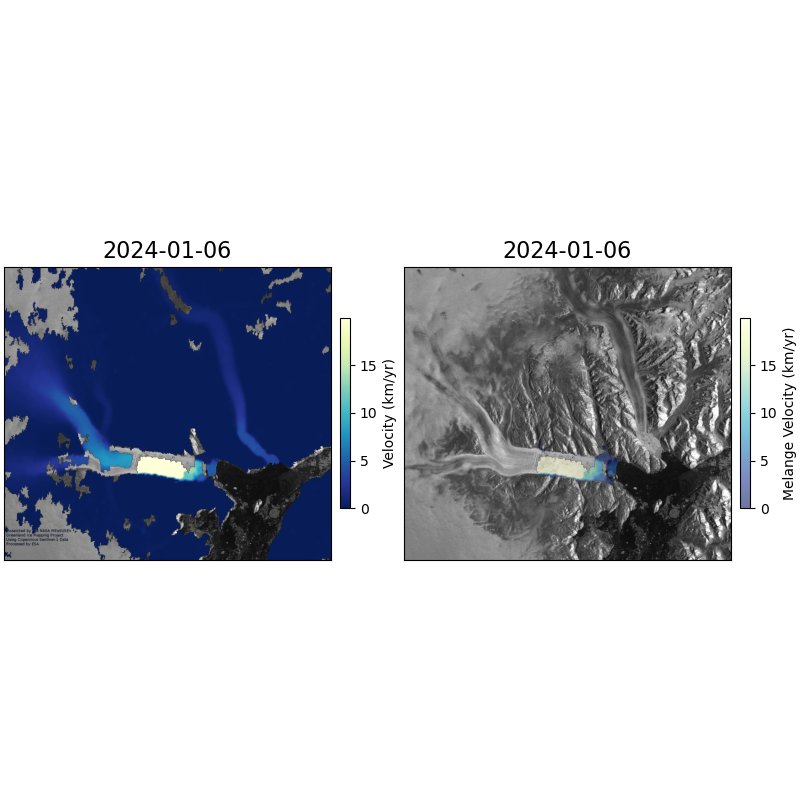

In [74]:
#Initialize figure and rendered declared artists prior to running animation function
ind = 408 #use random selector for initialized plot

f, hax = plt.subplots(ncols=2,figsize=(8,8), constrained_layout=True,layout='compressed')


overlay_raster1 = ds.velocity[ind,:,:].squeeze()
vm = 0.0007*np.nanmax(overlay_raster1)
#overlay_raster1_small = resize(overlay_raster1, (300, 300), anti_aliasing=True)
overlay_raster2 = ds.velocity_over_melange[ind,:,:].squeeze()
#overlay_raster2_small = resize(overlay_raster2, (300, 300), anti_aliasing=True)
#overlay_raster3 = ds.masked_mel_velocity[ind,:,:].squeeze()
#overlay_raster3_small = resize(overlay_raster3, (300, 300), anti_aliasing=True)

bw0 = rio.open_rasterio(cogsIM[ind]).squeeze()
bw1 = zoom(bw0, 0.5)
#bw1_small = resize(bw1, (300, 300), anti_aliasing=True)
artists = {}


# --- Initialize static background images (same image for all frames) ---
artists['img_bw1'] = hax[0].imshow(bw1,extent=extent_IM,cmap='gray',animated=True)
artists['img_bw2'] = hax[1].imshow(bw1,extent=extent_IM,cmap='gray',animated=True)
#artists['img_bw3'] = hax[2].imshow(bw1,extent=extent_IM,cmap='gray',animated=True)


#div = make_axes_locatable(ax)
#cax = div.append_axes('right', '5%', '5%')

# --- Initialize velocity overlays ---
artists['img_vel'] = hax[0].imshow(0.001*overlay_raster1,extent=extentMel,cmap="YlGnBu_r",
                      vmin=0., vmax=vm,animated=True)
#f.colorbar(artists['img_vel'], cax=None,shrink=0.5, pad=0.03, label='Velocity (km/yr)')
artists['img_mel'] = hax[1].imshow(0.001*overlay_raster2,extent=extentMel,cmap="YlGnBu_r",
                      vmin=0., vmax=vm,alpha=0.6,animated=True)
#artists['img_trimmed'] = hax[2].imshow(0.001*overlay_raster3,extent=extentMel,cmap="YlGnBu_r",
#                      vmin=0., vmax=vm,alpha=0.6,animated=True)



# --- Initialize titles ---
titles = [ax.set_title("") for ax in hax]




date_label = ds.time[ind].dt.strftime('%Y-%m-%d').item()


for ax in hax.ravel():
    ax.set_title(date_label,{'fontsize': 16})
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.set_xlim(v1[0], v1[2] - 2500) #(v1[0] + x_zoom - 5000,v1[2] - x_zoom)
    #ax.set_ylim(v1[1] + 2000, v1[3] - 2000)#(v1[1] + y_zoom - 7500,v1[3] - y_zoom/0.65)

# Add colorbars 
plt.colorbar(artists['img_vel'], cax=None, ax=hax[0], use_gridspec=True,shrink=0.65, pad=0.03, label='Velocity (km/yr)')
plt.colorbar(artists['img_mel'], cax=None, ax=hax[1], use_gridspec=True,shrink=0.65, pad=0.03, label='Melange Velocity (km/yr)')
#plt.colorbar(artists['img_trimmed'], cax=None, ax=hax[2], use_gridspec=True,shrink=0.65, pad=0.03, label='Trimmed Mel Velocity (km/yr)')
plt.show()

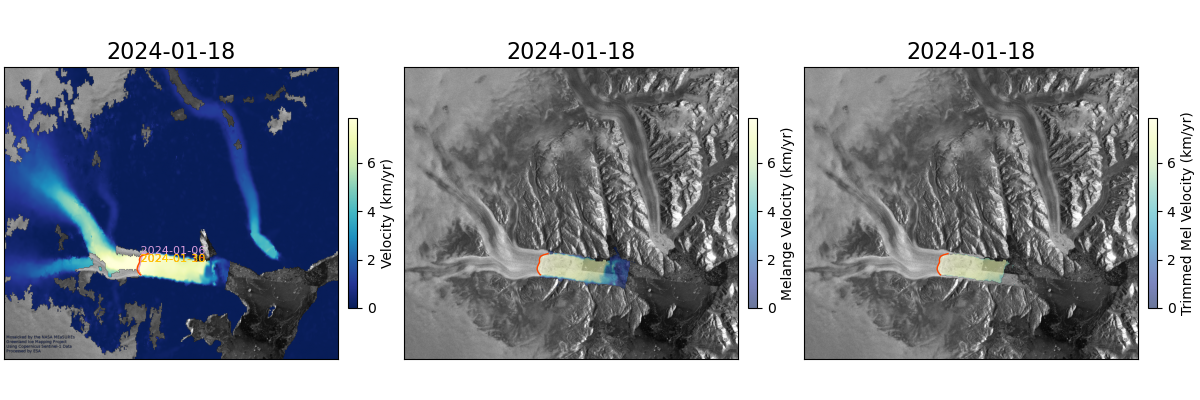

In [75]:
#Initialize figure and rendered declared artists prior to running animation function
ind = 409 #use random selector for initialized plot

f, hax = plt.subplots(ncols=3,figsize=(12,4), constrained_layout=True,layout='compressed')


overlay_raster1 = ds.velocity[ind,:,:].squeeze()
vm = 0.0009*np.nanmax(overlay_raster1)
#overlay_raster1_small = resize(overlay_raster1, (300, 300), anti_aliasing=True)
overlay_raster2 = ds.velocity_over_melange[ind,:,:].squeeze()
#overlay_raster2_small = resize(overlay_raster2, (300, 300), anti_aliasing=True)
overlay_raster3 = ds.masked_mel_velocity[ind,:,:].squeeze()
#overlay_raster3_small = resize(overlay_raster3, (300, 300), anti_aliasing=True)

bw0 = rio.open_rasterio(cogsIM[ind]).squeeze()
bw1 = zoom(bw0, 0.5)
#bw1_small = resize(bw1, (300, 300), anti_aliasing=True)
artists = {}


# --- Initialize static background images (same image for all frames) ---
artists['img_bw1'] = hax[0].imshow(bw1,extent=extent_IM,cmap='gray',animated=True)
artists['img_bw2'] = hax[1].imshow(bw1,extent=extent_IM,cmap='gray',animated=True)
artists['img_bw3'] = hax[2].imshow(bw1,extent=extent_IM,cmap='gray',animated=True)


#div = make_axes_locatable(ax)
#cax = div.append_axes('right', '5%', '5%')

# --- Initialize velocity overlays ---
artists['img_vel'] = hax[0].imshow(0.001*overlay_raster1,extent=extentMel,cmap="YlGnBu_r",
                      vmin=0., vmax=vm,animated=True)
#f.colorbar(artists['img_vel'], cax=None,shrink=0.5, pad=0.03, label='Velocity (km/yr)')
artists['img_mel'] = hax[1].imshow(0.001*overlay_raster2,extent=extentMel,cmap="YlGnBu_r",
                      vmin=0., vmax=vm,alpha=0.6,animated=True)
artists['img_trimmed'] = hax[2].imshow(0.001*overlay_raster3,extent=extentMel,cmap="YlGnBu_r",
                      vmin=0., vmax=vm,alpha=0.6,animated=True)



# --- Initialize titles ---
titles = [ax.set_title("") for ax in hax]

# --- Dynamically initialize line artists  --- 
artists["lines"] = {}
front_lines = []
line_colors = ['orangered','plum', 'gold']
inx = -1
for idx, offset in enumerate([-1, 1, 0]):    
    x_coords, y_coords = front_cache.get(ind - offset, ([], []))
    #line = front_data.loc[ind - offset, 'geometry']
    #x_coords, y_coords = line.xy
    for ax_i in ([hax[0]] if offset != 0 else hax):  # red line to all subplots 
        inx = inx + 1
        label = f"f{inx}"
        #print(label)
        line, = ax_i.plot(x_coords, y_coords, color=line_colors[offset], linewidth=1)
        artists['lines'][label] = line
        front_lines.append(line)


date_label = ds.time[ind].dt.strftime('%Y-%m-%d').item()
closest_front_label0 = front_data['Date'].iloc[ind].strftime('%Y-%m-%d')
closest_front_label1 = front_data['Date'].iloc[ind-1].strftime('%Y-%m-%d')
closest_front_label2 = front_data['Date'].iloc[ind+1].strftime('%Y-%m-%d')

x_coords, y_coords = front_cache.get(ind, ([], []))
    
    
artists['text0'] = hax[0].annotate(f' '+str(closest_front_label0),
        xy=(np.min(x_coords), np.mean(y_coords) + ((y_zoom/4 - y_zoom/5) + (y_zoom/4))), xycoords='data',
        fontsize=8,color=line_colors[0])

artists['text1'] = hax[0].annotate(f' '+str(closest_front_label1),
        xy=(np.min(x_coords), np.max(y_coords)+(y_zoom/4) ), xycoords='data',
        fontsize=8,color=line_colors[1])

artists['text2'] = hax[0].annotate(f' '+str(closest_front_label2),
        xy=(np.min(x_coords), np.mean(y_coords) + (y_zoom/5)), xycoords='data',
        fontsize=8,color=line_colors[2])

for ax in hax.ravel():
    ax.set_title(date_label,{'fontsize': 16})
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(v1[0], v1[2] - 2500) #(v1[0] + x_zoom - 5000,v1[2] - x_zoom)
    ax.set_ylim(v1[1] + 2000, v1[3] - 2000)#(v1[1] + y_zoom - 7500,v1[3] - y_zoom/0.65)

# Add colorbars 
plt.colorbar(artists['img_vel'], cax=None, ax=hax[0], use_gridspec=True,shrink=0.65, pad=0.03, label='Velocity (km/yr)')
plt.colorbar(artists['img_mel'], cax=None, ax=hax[1], use_gridspec=True,shrink=0.65, pad=0.03, label='Melange Velocity (km/yr)')
plt.colorbar(artists['img_trimmed'], cax=None, ax=hax[2], use_gridspec=True,shrink=0.65, pad=0.03, label='Trimmed Mel Velocity (km/yr)')
plt.show()

## Below, I define the update function used to change plotted data in each frame. To change plotting arguments and specs, edit the cell which initializes the figure axes and rendered artists rather than this block here ##

In [78]:
def update(frame,ds,front_cache,artists):

    
    frame0 = frame + 410
    print(frame0)

   # with rio.open_rasterio(cogsIM[frame0]).squeeze() as bw_data:
    bw_data0 = rio.open_rasterio(cogsIM[frame0]).squeeze()
    bw_data = zoom(bw_data0, 0.5)
    artists['img_bw1'].set_data(bw_data)
    artists['img_bw2'].set_data(bw_data)
    artists['img_bw3'].set_data(bw_data)
    
    overlay_raster1 = ds.velocity[frame0,:,:].squeeze()
    overlay_raster2 = ds.velocity_over_melange[frame0,:,:].squeeze()
    overlay_raster3 = ds.masked_mel_velocity[frame0,:,:].squeeze()

    # ---  Update raster overlays --- 
    artists['img_vel'].set_data(0.001 * overlay_raster1)
    artists['img_mel'].set_data(0.001 * overlay_raster2)
    artists['img_trimmed'].set_data(0.001 * overlay_raster3)

        
    # --- Update front line geometries dynamically---
    updated_lines = []
    frame_offset = [0, -1, 1]; # current time, the previous available temrinus, and the next available terminus
    for ax_idx, lines in enumerate(front_lines):
        label = f"f{ax_idx}"
        if ax_idx < 3:
            x_coords, y_coords = front_cache.get(frame0 + frame_offset[ax_idx], ([], []))
            artists['lines'][label].set_data(x_coords, y_coords)
            lines.set_data(x_coords, y_coords)
        else:
            x_coords, y_coords = front_cache.get(frame0, ([], []))
            lines.set_data(x_coords, y_coords)
            artists['lines'][label].set_data(x_coords, y_coords)
        updated_lines.append(lines)


    x_coords, y_coords = front_cache.get(frame0, ([], []))


    #  --- Update existing annotations  --- 
    if len(x_coords) > 0 and len(y_coords) > 0:
        
        artists['text0'].set_text(front_data['Date'].iloc[frame0].strftime('%Y-%m-%d'))
        artists['text0'].set_position([np.min(x_coords), (np.mean(y_coords) + ((y_zoom/4 - y_zoom/5) + (y_zoom/4)))])
        artists['text1'].set_text(front_data['Date'].iloc[frame0 - 1].strftime('%Y-%m-%d'))
        artists['text1'].set_position([np.min(x_coords), (np.max(y_coords)+(y_zoom/4))])
        #don't plot next termini if on last frame of animation
        if (frame0 < (len(front_data) - 1)): 
            artists['text2'].set_text(front_data['Date'].iloc[frame0 + 1].strftime('%Y-%m-%d'))
            artists['text2'].set_position([np.min(x_coords), (np.mean(y_coords) + (y_zoom/5))])
        else:
            artists['text2'].set_text("")
    else:
        artists['text0'].set_text("")
        artists['text1'].set_text("")
        artists['text2'].set_text("")


    # Titles — from xarray datetime
    date_label = ds.time[frame0].dt.strftime('%Y-%m-%d').item()
    for i, ax in enumerate(hax):
        ax.set_title(date_label)
        ax.set_xticks([])
        ax.set_yticks([])
        #ax.set_xlim(v1[0] + x_zoom - 10000, v1[2] - x_zoom)
        #ax.set_ylim(v1[1] + y_zoom - 10000,v1[3] - y_zoom)
    

    return [artists['img_bw1'], artists['img_bw2'], artists['img_bw3'],
        artists['img_vel'], artists['img_mel'], artists['img_trimmed'],
        *front_lines, artists['text0'], artists['text1'], artists['text2']]

In [79]:
dir_2 = 'melange_anim_results';
# Get current timestamp
nowt = datetime.datetime.now()

# Format as a string 
timestamp_plt = nowt.strftime("%Y%m%d")  # e.g., 20251010

# Create dynamic filename
filename = f"{name}_animation_{timestamp_plt}.mp4"
#nframes = 5 #len(cogsM) #create animation for the full time period (All available velocity maps)
ani = animation.FuncAnimation(f, update, frames=53, fargs=(ds,front_cache,artists), interval=100, blit=True)#interval=300
#HTML(ani.to_jshtml())
ani.save("helheim_motion_2025.mp4", writer="ffmpeg", fps=4)

410
410
411
412
413
414
415
416
417
418
419
420
421
422
423
424
425
426
427
428
429
430
431
432
433
434
435
436
437
438
439
440
441
442
443
444
445
446
447
448
449
450
451
452
453
454
455
456
457
458
459
460
461
462


In [ ]:
HTML(ani.to_jshtml())